# Experiment 2026-07-13 — exploration length by propagation model

**Primary question:** how many early campaigns should be assigned to exploration before switching to exploitation, and does that choice depend on the true propagation model?

The notebook is deliberately decision-first. After the experiment runs, look at **Results at a glance** before the optional diagnostics.

Main outputs:

1. paired gain of each exploration count relative to \(k=0\);
2. best \(k\) for every propagation model and identifier;
3. sensitivity to choosing a non-optimal \(k\);
4. raw performance curves with confidence intervals.

The default study enables linear consensus, COCA, and Hegselmann--Krause. To run every implemented propagation model, set `RUN_ALL_IMPLEMENTED_DYNAMICS = True` in the configuration cell. To choose a custom subset, edit the single `ENABLED_DYNAMICS` list.

**Identifier paths used here:** the nonlinear online policy uses `opinion_dynamics.identify_nonlinear.GraphIdentifierEnv`; the linear comparison uses the notebook-local `PaperLinearGraphIdentifier`. The legacy `opinion_dynamics.identify` module is not used by this notebook.


In [1]:
from __future__ import annotations

import contextlib
import io
import inspect
import math
import os
import random
import time
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / "opinion_dynamics").exists():
            return p
    raise RuntimeError(
        "Could not find repo root containing opinion_dynamics/. "
        "Run this notebook from the repo or set REPO_ROOT manually."
    )


REPO_ROOT = find_repo_root()
print("REPO_ROOT:", REPO_ROOT)

import sys
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from rl_envs_forge.envs.network_graph.graph_utils import (
    compute_laplacian,
    compute_eigenvector_centrality,
)
from opinion_dynamics.utils.env_setup import EnvironmentFactory
from opinion_dynamics.baseline import centrality_based_continuous_control

# Import the module itself because this notebook patches its environment-cloning
# helpers before calling the nonlinear online runner.
import opinion_dynamics.experiments.online_single_shot as online_single_shot_module

run_single_shot_online_identification = (
    online_single_shot_module.run_single_shot_online_identification
)

C:\Users\Chainsword\AppData\Local\Temp\ipykernel_5948\1952117008.py:14: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


REPO_ROOT: d:\Work\repos\RL\unknown_graph_networks


## Configuration


The default `QUICK_RUN=True` mode uses two topology seeds, two initial-state seeds, and shorter fits. Switch it off only for the final larger replication study.


In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using DEVICE:", DEVICE)

STUDY_DATE = "2026_07_13"
STUDY_NAME = "exploration_campaign_sweep_by_propagation_model"
RESULTS_DIR = (
    REPO_ROOT
    / "opinion_dynamics"
    / "experiments"
    / "results"
    / f"experiment_{STUDY_DATE}_{STUDY_NAME}"
)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("Results dir:", RESULTS_DIR)

# ---------------------------------------------------------------------------
# Propagation-model registry
# ---------------------------------------------------------------------------
# Exact model names supported by the current NetworkGraph implementation.
# "degroot" is not listed separately because it aliases "laplacian".
DYNAMICS_SPECS = {
    "laplacian": {
        "label": "Linear consensus",
        "env_kwargs": {},
    },
    "coca": {
        "label": "COCA",
        "env_kwargs": {},
    },
    "hegselmannkrause": {
        "label": "Hegselmann--Krause",
        "env_kwargs": {
            "hk_epsilon": 0.20,
            "hk_include_self": True,
        },
    },
    "friedkinjohnsen": {
        "label": "Friedkin--Johnsen",
        "env_kwargs": {
            "fj_lambda": 0.99,
            # None means that the trial's initial opinion vector is used.
            "fj_prejudice": None,
        },
    },
    "nonlinearinfluence": {
        "label": "Nonlinear influence",
        "env_kwargs": {
            "nonlinear_beta": 2.0,
        },
    },
    "repulsion": {
        "label": "Repulsion",
        "env_kwargs": {
            "repulsion_epsilon": 0.20,
            "repulsion_strength": 0.5,
        },
    },
}

# ----------------------------- USER CONTROL -----------------------------
# One switch runs every implemented propagation model.
RUN_ALL_IMPLEMENTED_DYNAMICS = False

# Otherwise edit only this list. Uncommenting a name is sufficient.
ENABLED_DYNAMICS = [
    "laplacian",
    "coca",
    "hegselmannkrause",
    # "friedkinjohnsen",
    # "nonlinearinfluence",
    # "repulsion",
]

# Run a one-step constructor/propagation check before the expensive sweep.
RUN_DYNAMICS_PREFLIGHT = True
# ----------------------------------------------------------------------

if RUN_ALL_IMPLEMENTED_DYNAMICS:
    ENABLED_DYNAMICS = list(DYNAMICS_SPECS)

unknown_dynamics = sorted(set(ENABLED_DYNAMICS) - set(DYNAMICS_SPECS))
if unknown_dynamics:
    raise ValueError(
        f"Unknown propagation models: {unknown_dynamics}. "
        f"Available names: {list(DYNAMICS_SPECS)}"
    )
if not ENABLED_DYNAMICS:
    raise ValueError("Enable at least one propagation model.")

DYNAMICS_LABELS = {
    name: spec["label"] for name, spec in DYNAMICS_SPECS.items()
}

# ---------------------------------------------------------------------------
# Runtime mode and replication grid
# ---------------------------------------------------------------------------
# QUICK_RUN keeps the full 0--10 exploration sweep and all enabled
# propagation models, but uses fewer seeds and shorter identifier fits.
# Set QUICK_RUN=False for the slower paper-quality replication study.
QUICK_RUN = True
FAIL_FAST = True
SAVE_PROGRESS_EVERY_CONDITION = True

if QUICK_RUN:
    TOPOLOGY_SEEDS = [3, 4]
    INITIAL_PERMUTATION_SEEDS = [0, 1]
else:
    TOPOLOGY_SEEDS = [3, 4, 5]
    INITIAL_PERMUTATION_SEEDS = [0, 1, 2]

# Paper-style graph and control constants.
N_AGENTS = 15
OMEGA = 1.0
U_BAR = 0.2

# Campaign setting.
NUM_CAMPAIGNS_TOTAL = 20
T_CAMPAIGN = 0.5
T_S = 0.05
TOTAL_CONTROLLED_BUDGET = 4.5
B_CAMPAIGN = TOTAL_CONTROLLED_BUDGET / (NUM_CAMPAIGNS_TOTAL - 1)
LEARNED_POLICY_LAMBDA = 0.70

# Campaign 0 is passive. Campaigns 1..k are epsilon-mixed exploration,
# followed by pure exploitation.
EXPLORATION_CAMPAIGN_COUNTS = list(range(0, 11))
EPSILON_START = 1.0
EPSILON_END = 0.1

# Identifier fitting settings.
LR = 1e-3
L2_LAMBDA = 0.0
SWEEP_FIT_MAX_STEPS = 300 if QUICK_RUN else 1_000
SWEEP_FIT_MAE_STOP = 5e-4
SWEEP_FIT_BATCH_SIZE = 256
SWEEP_FIT_CHECK_EVERY = 100 if QUICK_RUN else 200
IDENTIFIER_KW_NONLINEAR = {"hidden_dim": 16}

INITIAL_STATE_SEED_BASE = 920_000
TRAIN_SEED_BASE = 421_000
TRIAL_RNG_SEED_BASE = 731_000

KEEP_TRIAL_ARTIFACTS = False
SUPPRESS_FIT_LOGS = True

# Diagnostics shown after the decision-focused result section.
SELECT_EXPLORATION_COUNTS_FOR_TRAJECTORIES = [0, 2, 5, 10]


def make_epsilon_schedule(
    num_campaigns_total: int,
    exploration_campaigns: int,
    eps_start: float = 1.0,
    eps_end: float = 0.1,
) -> list[float]:
    """Campaign 0 is passive; campaigns 1..k linearly decay epsilon."""
    if num_campaigns_total < 1:
        raise ValueError("num_campaigns_total must be >= 1")
    exploration_campaigns = int(
        min(max(0, exploration_campaigns), num_campaigns_total - 1)
    )
    schedule = [0.0]
    if exploration_campaigns > 0:
        if exploration_campaigns == 1:
            schedule.append(float(eps_start))
        else:
            schedule.extend(
                np.linspace(
                    float(eps_start),
                    float(eps_end),
                    exploration_campaigns,
                ).tolist()
            )
    schedule.extend([0.0] * (num_campaigns_total - len(schedule)))
    return [float(e) for e in schedule]


CONDITIONS = []
for k in EXPLORATION_CAMPAIGN_COUNTS:
    CONDITIONS.append(
        {
            "condition": f"explore_{int(k):02d}",
            "condition_label": f"{int(k)} exploration campaigns",
            "fit_max_steps": int(SWEEP_FIT_MAX_STEPS),
            "fit_mae_stop": float(SWEEP_FIT_MAE_STOP),
            "fit_batch_size": int(SWEEP_FIT_BATCH_SIZE),
            "fit_check_every": int(SWEEP_FIT_CHECK_EVERY),
            "exploration_campaigns": int(k),
            "epsilon_schedule": make_epsilon_schedule(
                NUM_CAMPAIGNS_TOTAL,
                int(k),
                EPSILON_START,
                EPSILON_END,
            ),
        }
    )

for cond in CONDITIONS:
    assert len(cond["epsilon_schedule"]) == NUM_CAMPAIGNS_TOTAL
    assert cond["epsilon_schedule"][0] == 0.0

config_summary = {
    "study_name": STUDY_NAME,
    "quick_run": QUICK_RUN,
    "fail_fast": FAIL_FAST,
    "enabled_dynamics": ENABLED_DYNAMICS,
    "topology_seeds": TOPOLOGY_SEEDS,
    "initial_permutation_seeds": INITIAL_PERMUTATION_SEEDS,
    "exploration_campaign_counts": EXPLORATION_CAMPAIGN_COUNTS,
    "n_trials_per_dynamics_and_k": (
        len(TOPOLOGY_SEEDS) * len(INITIAL_PERMUTATION_SEEDS)
    ),
    "n_learned_rollouts_expected": (
        len(ENABLED_DYNAMICS)
        * len(CONDITIONS)
        * len(TOPOLOGY_SEEDS)
        * len(INITIAL_PERMUTATION_SEEDS)
        * 2
    ),
    "num_campaigns_total": NUM_CAMPAIGNS_TOTAL,
    "controlled_campaigns": NUM_CAMPAIGNS_TOTAL - 1,
    "t_campaign": T_CAMPAIGN,
    "t_s": T_S,
    "B_campaign": B_CAMPAIGN,
    "total_controlled_budget": TOTAL_CONTROLLED_BUDGET,
    "lambda_mix": LEARNED_POLICY_LAMBDA,
}
config_summary


Using DEVICE: cpu
Results dir: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_13_exploration_campaign_sweep_by_propagation_model


{'study_name': 'exploration_campaign_sweep_by_propagation_model',
 'quick_run': True,
 'fail_fast': True,
 'enabled_dynamics': ['laplacian', 'coca', 'hegselmannkrause'],
 'topology_seeds': [3, 4],
 'initial_permutation_seeds': [0, 1],
 'exploration_campaign_counts': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 'n_trials_per_dynamics_and_k': 4,
 'n_learned_rollouts_expected': 264,
 'num_campaigns_total': 20,
 'controlled_campaigns': 19,
 't_campaign': 0.5,
 't_s': 0.05,
 'B_campaign': 0.23684210526315788,
 'total_controlled_budget': 4.5,
 'lambda_mix': 0.7}

## Shared helpers

One topology is generated per topology seed and reused across all enabled propagation models. This makes cross-model comparisons depend on the propagation law rather than on different sampled graphs.

The nonlinear online runner is imported as a module and patched locally so that model-specific environment parameters (for example `hk_epsilon`, `fj_lambda`, `nonlinear_beta`, and repulsion parameters) survive environment cloning.

The cloning helper inspects the installed `NetworkGraph` constructor. If an enabled model requires arguments missing from an older local `rl-envs-forge` checkout, the notebook raises a targeted update error instead of silently substituting defaults.


In [3]:
def set_global_seed(seed: int) -> None:
    seed = int(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def as_vector_max_u(max_u: Any, n: int) -> np.ndarray:
    u = np.asarray(max_u, dtype=float)
    if u.ndim == 0:
        return np.full(n, float(u), dtype=float)
    u = u.reshape(-1).astype(float)
    if u.shape != (n,):
        raise ValueError(f"max_u must be scalar or shape ({n},), got {u.shape}")
    return u


def sanitize_centrality(v: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    v = np.asarray(v, dtype=float).reshape(-1)
    v = np.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0)
    if v.sum() < 0:
        v = -v
    v = np.maximum(v, 0.0)
    s = float(v.sum())
    if s <= eps:
        v = np.abs(v)
        s = float(v.sum())
    if s <= eps:
        return np.full_like(v, 1.0 / len(v))
    return v / s


def centrality_from_A(A: np.ndarray) -> np.ndarray:
    return sanitize_centrality(
        compute_eigenvector_centrality(compute_laplacian(np.asarray(A, dtype=float)))
    )


def make_paper_initial_opinions(n: int, permutation_seed: int) -> np.ndarray:
    rng = np.random.default_rng(INITIAL_STATE_SEED_BASE + int(permutation_seed))
    x = np.linspace(0.0, 1.0, int(n), dtype=float)
    return rng.permutation(x)


def set_initial_state(env: Any, x0: np.ndarray) -> None:
    x0 = np.asarray(x0, dtype=float).reshape(-1)
    if hasattr(env, "initial_opinions"):
        try:
            env.initial_opinions = x0.copy()
        except Exception:
            pass
    env.opinions = x0.copy()
    if hasattr(env, "state"):
        try:
            env.state = x0.copy()
        except Exception:
            pass
    # When FJ prejudice was not explicitly supplied, use the trial's x0.
    if str(getattr(env, "dynamics_model", "")).lower() in {
        "friedkinjohnsen", "friedkin_johnsen", "fj"
    }:
        env.fj_prejudice = x0.copy()



def _copy_env_value(value: Any) -> Any:
    """Copy arrays while leaving scalar/configuration values unchanged."""
    if isinstance(value, np.ndarray):
        return np.array(value, copy=True)
    if isinstance(value, (list, tuple)):
        return type(value)(value)
    return value


def _filter_constructor_kwargs(
    EnvCls: type,
    kwargs: Dict[str, Any],
    *,
    required_keys: Iterable[str] = (),
) -> Dict[str, Any]:
    """Keep only arguments accepted by the installed environment class.

    Dynamics-specific arguments are treated as required. If the local
    rl-envs-forge checkout is too old to accept one of them, fail with a
    targeted upgrade message instead of silently running the wrong model.
    """
    signature = inspect.signature(EnvCls.__init__)
    parameters = signature.parameters
    accepts_var_kwargs = any(
        p.kind == inspect.Parameter.VAR_KEYWORD
        for p in parameters.values()
    )
    if accepts_var_kwargs:
        return dict(kwargs)

    accepted = {
        name
        for name, p in parameters.items()
        if name != "self"
        and p.kind
        in {
            inspect.Parameter.POSITIONAL_OR_KEYWORD,
            inspect.Parameter.KEYWORD_ONLY,
        }
    }
    unsupported = sorted(set(kwargs) - accepted)
    required_unsupported = sorted(set(required_keys) - accepted)
    if required_unsupported:
        raise RuntimeError(
            "The installed NetworkGraph constructor does not support "
            f"{required_unsupported}. Update the local rl-envs-forge checkout "
            "before enabling this propagation model."
        )
    if unsupported:
        print(
            "Ignoring nonessential constructor arguments not supported by "
            f"{EnvCls.__name__}: {unsupported}"
        )
    return {k: v for k, v in kwargs.items() if k in accepted}


def env_kwargs_from_template(
    env_template: Any,
    *,
    dynamics_model: Optional[str] = None,
    dynamics_overrides: Optional[Dict[str, Any]] = None,
    t_campaign: float = T_CAMPAIGN,
    t_s: float = T_S,
    omega: float = OMEGA,
    u_bar: float = U_BAR,
    terminate_when_converged: bool = False,
) -> Dict[str, Any]:
    """Extract constructor arguments while preserving model-specific settings."""
    n = int(env_template.num_agents)
    model_name = str(
        dynamics_model
        if dynamics_model is not None
        else getattr(env_template, "dynamics_model", "laplacian")
    )

    initial_opinions = getattr(env_template, "initial_opinions", None)
    kwargs: Dict[str, Any] = dict(
        connectivity_matrix=np.array(
            env_template.connectivity_matrix,
            copy=True,
        ),
        num_agents=n,
        max_u=np.full(n, float(u_bar), dtype=float),
        desired_opinion=float(omega),
        t_campaign=float(t_campaign),
        t_s=float(t_s),
        dynamics_model=model_name,
        initial_opinions=(
            None
            if initial_opinions is None
            else np.array(initial_opinions, copy=True)
        ),
        initial_opinion_range=tuple(
            getattr(env_template, "initial_opinion_range", (0.0, 1.0))
        ),
        control_resistance=np.array(
            getattr(env_template, "control_resistance", np.zeros(n)),
            copy=True,
        ),
        max_steps=int(getattr(env_template, "max_steps", 10_000)),
        opinion_end_tolerance=float(
            getattr(env_template, "opinion_end_tolerance", 0.01)
        ),
        control_beta=float(getattr(env_template, "control_beta", 0.4)),
        normalize_reward=bool(
            getattr(env_template, "normalize_reward", False)
        ),
        terminal_reward=float(
            getattr(env_template, "terminal_reward", 0.0)
        ),
        terminate_when_converged=bool(terminate_when_converged),
        budget=getattr(env_template, "budget", None),
        use_delta_shaping=bool(
            getattr(env_template, "use_delta_shaping", False)
        ),
        delta_lambda=float(getattr(env_template, "delta_lambda", 0.0)),
        seed=(
            int(getattr(env_template, "seed", 0))
            if getattr(env_template, "seed", None) is not None
            else None
        ),
    )

    # These parameters cover every propagation model implemented by the
    # current NetworkGraph environment.
    for attr in [
        "fj_lambda",
        "fj_prejudice",
        "hk_epsilon",
        "hk_include_self",
        "nonlinear_beta",
        "repulsion_epsilon",
        "repulsion_strength",
    ]:
        if hasattr(env_template, attr):
            kwargs[attr] = _copy_env_value(getattr(env_template, attr))

    if dynamics_overrides:
        for key, value in dynamics_overrides.items():
            # FJ prejudice is filled from x0 later when left as None.
            kwargs[key] = _copy_env_value(value)

    required_keys = set((dynamics_overrides or {}).keys())
    return _filter_constructor_kwargs(
        env_template.__class__,
        kwargs,
        required_keys=required_keys,
    )


def clone_env_from_template(
    env_template: Any,
    *,
    dynamics_model: Optional[str] = None,
    dynamics_overrides: Optional[Dict[str, Any]] = None,
    t_campaign: float = T_CAMPAIGN,
    t_s: float = T_S,
    omega: float = OMEGA,
    u_bar: float = U_BAR,
    terminate_when_converged: bool = False,
) -> Any:
    """Clone a NetworkGraph while preserving propagation-specific parameters."""
    kwargs = env_kwargs_from_template(
        env_template,
        dynamics_model=dynamics_model,
        dynamics_overrides=dynamics_overrides,
        t_campaign=t_campaign,
        t_s=t_s,
        omega=omega,
        u_bar=u_bar,
        terminate_when_converged=terminate_when_converged,
    )
    return env_template.__class__(**kwargs)


def make_topology_template(topology_seed: int) -> Any:
    """Generate one graph that is reused across every propagation model."""
    factory = EnvironmentFactory()
    return factory.get_randomized_env(
        seed=int(topology_seed),
        dynamics_model="laplacian",
    )


def make_env_for_dynamics(env_template: Any, dynamics: str) -> Any:
    if dynamics not in DYNAMICS_SPECS:
        raise KeyError(f"Unknown dynamics specification: {dynamics}")
    return clone_env_from_template(
        env_template,
        dynamics_model=dynamics,
        dynamics_overrides=DYNAMICS_SPECS[dynamics]["env_kwargs"],
        t_campaign=T_CAMPAIGN,
        t_s=T_S,
        omega=OMEGA,
        u_bar=U_BAR,
        terminate_when_converged=False,
    )


def online_env_kwargs_from_env(
    env: Any,
    *,
    t_campaign: Optional[float] = None,
    t_s: Optional[float] = None,
) -> Dict[str, Any]:
    """Cloning hook used inside online_single_shot.

    It preserves all model-specific parameters instead of reverting them to
    NetworkGraph defaults.
    """
    return env_kwargs_from_template(
        env,
        dynamics_model=str(
            getattr(env, "dynamics_model", "laplacian")
        ),
        dynamics_overrides=None,
        t_campaign=float(
            env.t_campaign if t_campaign is None else t_campaign
        ),
        t_s=float(env.t_s if t_s is None else t_s),
        omega=float(env.desired_opinion),
        u_bar=float(np.asarray(env.max_u).reshape(-1)[0]),
        terminate_when_converged=bool(
            getattr(env, "terminate_when_converged", False)
        ),
    )


def online_make_env_from_template(
    env_template: Any,
    *,
    t_campaign: Optional[float] = None,
    t_s: Optional[float] = None,
) -> Any:
    kwargs = online_env_kwargs_from_env(
        env_template,
        t_campaign=t_campaign,
        t_s=t_s,
    )
    return env_template.__class__(**kwargs)


# Patch only the two cloning hooks used internally by the imported runner.
online_single_shot_module.env_kwargs_from_env = online_env_kwargs_from_env
online_single_shot_module.make_env_from_template = (
    online_make_env_from_template
)
run_single_shot_online_identification = (
    online_single_shot_module.run_single_shot_online_identification
)


def pairs_from_intermediate(intermediate_states: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    inter = np.asarray(intermediate_states, dtype=float)
    return inter[:-1], inter[1:]


def normalize_scores(scores: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    s = np.asarray(scores, dtype=float).reshape(-1)
    s = np.nan_to_num(s, nan=0.0, posinf=0.0, neginf=0.0)
    s = np.maximum(s, 0.0)
    m = float(s.max()) if s.size else 0.0
    if m <= eps:
        return np.ones_like(s)
    return s / m


def waterfill_from_scores(scores: np.ndarray, max_u: np.ndarray, budget: float) -> np.ndarray:
    scores = np.asarray(scores, dtype=float).reshape(-1)
    max_u = np.asarray(max_u, dtype=float).reshape(-1)
    if scores.shape != max_u.shape:
        raise ValueError(f"scores and max_u shape mismatch: {scores.shape} vs {max_u.shape}")

    u = np.zeros_like(scores, dtype=float)
    remaining = min(float(budget), float(max_u.sum()))
    if remaining <= 0:
        return u

    order = np.argsort(scores)[::-1]
    for i in order:
        if remaining <= 1e-12:
            break
        if scores[i] <= 0 and np.any(scores > 0):
            break
        assign = min(float(max_u[i]), remaining)
        if assign > 0:
            u[i] = assign
            remaining -= assign
    return u


def uniform_budget_action(max_u: np.ndarray, budget: float) -> np.ndarray:
    max_u = np.asarray(max_u, dtype=float).reshape(-1)
    n = max_u.size
    u = np.zeros(n, dtype=float)
    remaining = min(float(budget), float(max_u.sum()))
    active = np.ones(n, dtype=bool)
    while remaining > 1e-12 and active.any():
        idxs = np.where(active)[0]
        share = remaining / len(idxs)
        progressed = False
        for i in idxs:
            add = min(share, float(max_u[i] - u[i]))
            if add > 0:
                u[i] += add
                remaining -= add
                progressed = True
            if u[i] >= max_u[i] - 1e-12:
                active[i] = False
        if not progressed:
            break
    return u


def step_env_collect(env: Any, action: np.ndarray) -> Tuple[np.ndarray, float, bool, bool, np.ndarray]:
    x_next, reward, done, truncated, info = env.step(np.asarray(action, dtype=float))
    inter = info.get("intermediate_states", None)
    if inter is None:
        raise RuntimeError("env.step did not return info['intermediate_states']")
    return np.asarray(x_next, dtype=float), float(reward), bool(done), bool(truncated), np.asarray(inter, dtype=float)

### Propagation-model preflight

This inexpensive check constructs every enabled model and performs one zero-control campaign before the full sweep. It catches misspelled model names, stale environment installations, and invalid model-specific parameters early.


In [4]:
def preflight_enabled_dynamics() -> pd.DataFrame:
    topology_template = make_topology_template(TOPOLOGY_SEEDS[0])
    x0 = make_paper_initial_opinions(
        topology_template.num_agents,
        INITIAL_PERMUTATION_SEEDS[0],
    )
    rows = []

    for dynamics in ENABLED_DYNAMICS:
        env = make_env_for_dynamics(topology_template, dynamics)
        env.reset()
        set_initial_state(env, x0)

        zero_action = np.zeros(env.num_agents, dtype=float)
        x_next, reward, done, truncated, info = env.step(zero_action)
        inter = np.asarray(
            info.get("intermediate_states", []),
            dtype=float,
        )
        if inter.ndim != 2 or inter.shape[1] != env.num_agents:
            raise RuntimeError(
                f"{dynamics} returned invalid intermediate_states "
                f"with shape {inter.shape}."
            )

        rows.append(
            {
                "dynamics": dynamics,
                "label": DYNAMICS_LABELS[dynamics],
                "n_agents": int(env.num_agents),
                "substeps": int(max(0, inter.shape[0] - 1)),
                "finite": bool(np.isfinite(x_next).all()),
                "within_unit_interval": bool(
                    np.all(np.asarray(x_next) >= -1e-9)
                    and np.all(np.asarray(x_next) <= 1.0 + 1e-9)
                ),
                "reward": float(reward),
                "done": bool(done),
                "truncated": bool(truncated),
            }
        )

    result = pd.DataFrame(rows)
    if not result["finite"].all():
        raise RuntimeError(
            "At least one enabled propagation model produced non-finite states."
        )
    return result


if RUN_DYNAMICS_PREFLIGHT:
    preflight_df = preflight_enabled_dynamics()
    display(preflight_df)
else:
    print("Propagation-model preflight disabled.")


,dynamics,label,n_agents,substeps,finite,within_unit_interval,reward,done,truncated
0,laplacian,Linear consensus,15,10,True,True,-0.496618,False,False
1,coca,COCA,15,10,True,True,-0.500286,False,False
2,hegselmannkrause,Hegselmann--Krause,15,10,True,True,-0.499626,False,False


In [5]:
class PaperLinearGraphIdentifier(nn.Module):
    """Row-stochastic zero-diagonal linear Euler identifier."""

    def __init__(self, N: int, s: float, l2_lambda: float = 0.0, zero_diag: bool = True):
        super().__init__()
        self.N = int(N)
        self.s = float(s)
        self.l2_lambda = float(l2_lambda)
        self.zero_diag = bool(zero_diag)
        self.Theta = nn.Parameter(torch.zeros(self.N, self.N))
        nn.init.kaiming_uniform_(self.Theta, a=0.0)
        self.register_buffer("_diag_mask", 1.0 - torch.eye(self.N))
        self.last_fit_info = {}

    def A_hat(self) -> torch.Tensor:
        A = F.softmax(self.Theta, dim=1)
        if self.zero_diag:
            A = A * self._diag_mask
            rs = A.sum(dim=1, keepdim=True)
            rs = torch.where(rs > 0, rs, torch.ones_like(rs))
            A = A / rs
        return A

    def predict_next(self, x: torch.Tensor) -> torch.Tensor:
        A = self.A_hat()
        neighbor_avg = x @ A.T
        return x + self.s * (neighbor_avg - x)

    def loss(self, x: torch.Tensor, x_next: torch.Tensor):
        pred = self.predict_next(x)
        mse = F.mse_loss(pred, x_next)
        l2 = (self.Theta ** 2).sum()
        return mse + self.l2_lambda * l2, {"mse": mse.detach(), "l2": l2.detach()}


def train_paper_linear_identifier(
    model: PaperLinearGraphIdentifier,
    data_x: np.ndarray,
    data_x_next: np.ndarray,
    *,
    lr: float = LR,
    batch_size: int = SWEEP_FIT_BATCH_SIZE,
    max_steps: int = SWEEP_FIT_MAX_STEPS,
    mae_stop: float = SWEEP_FIT_MAE_STOP,
    fit_check_every: int = SWEEP_FIT_CHECK_EVERY,
    device: str = DEVICE,
    suppress_logs: bool = SUPPRESS_FIT_LOGS,
) -> Tuple[np.ndarray, Dict[str, Any]]:
    model.to(device)
    X = torch.tensor(np.asarray(data_x, dtype=np.float32), dtype=torch.float32, device=device)
    Y = torch.tensor(np.asarray(data_x_next, dtype=np.float32), dtype=torch.float32, device=device)
    n = int(X.shape[0])
    if n == 0:
        raise ValueError("No training pairs provided.")

    opt = torch.optim.Adam(model.parameters(), lr=float(lr))
    stop_reason = "max_steps"
    last_mae = float("nan")
    t0 = time.perf_counter()

    for step in range(int(max_steps)):
        idx = torch.randint(0, n, (min(int(batch_size), n),), device=device)
        loss, _ = model.loss(X[idx], Y[idx])
        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % int(fit_check_every) == 0 or step == int(max_steps) - 1:
            with torch.no_grad():
                yhat = model.predict_next(X)
                mae = float((yhat - Y).abs().mean().item())
                last_mae = mae
            if (not suppress_logs) and (step % 2000 == 0 or mae <= mae_stop):
                print(f"[linear-fit] step={step} mae={mae:.5g} n_pairs={n}")
            if mae <= float(mae_stop):
                stop_reason = "mae_stop"
                break

    fit_time = time.perf_counter() - t0
    with torch.no_grad():
        A = model.A_hat().detach().cpu().numpy()
        yhat = model.predict_next(X)
        final_mae = float((yhat - Y).abs().mean().item())
        identity_mae = float((X - Y).abs().mean().item())

    info = {
        "steps_run": int(step + 1),
        "stop_reason": stop_reason,
        "train_mae": final_mae,
        "identity_mae": identity_mae,
        "model_over_identity": final_mae / (identity_mae + 1e-12),
        "n_pairs": n,
        "fit_time_sec": float(fit_time),
    }
    model.last_fit_info = info
    return A, info

## Rollout routines


In [6]:
def rollout_fixed_policy_single_shot(
    env_template: Any,
    x0: np.ndarray,
    *,
    policy_name: str,
    v_policy: Optional[np.ndarray] = None,
    num_campaigns_total: int = NUM_CAMPAIGNS_TOTAL,
    B_campaign: float = B_CAMPAIGN,
    zero_first_campaign: bool = True,
) -> Dict[str, Any]:
    env = clone_env_from_template(env_template, terminate_when_converged=False)
    env.reset()
    set_initial_state(env, x0)

    states = [np.asarray(x0, dtype=float).copy()]
    actions = []
    rewards = []
    boundary_times = [0.0]
    intermediate_states_list = []

    max_u = as_vector_max_u(env.max_u, env.num_agents)

    for k in range(int(num_campaigns_total)):
        if policy_name == "no_control" or (zero_first_campaign and k == 0):
            u = np.zeros(env.num_agents, dtype=float)
        elif policy_name == "uniform":
            u = uniform_budget_action(max_u, B_campaign)
        elif policy_name in {"oracle_true_v", "true_graph_centrality"}:
            if v_policy is None:
                raise ValueError("v_policy is required for true-graph centrality")
            u, _ = centrality_based_continuous_control(env, B_campaign, v=v_policy)
        else:
            raise ValueError(f"Unknown policy_name={policy_name}")

        x_next, r, done, trunc, inter = step_env_collect(env, u)
        actions.append(u.copy())
        rewards.append(r)
        states.append(x_next.copy())
        intermediate_states_list.append(inter.copy())
        boundary_times.append(boundary_times[-1] + float(env.t_campaign))

        if done or trunc:
            break

    return {
        "policy": policy_name,
        "states": np.asarray(states, dtype=float),
        "actions": np.asarray(actions, dtype=float),
        "rewards": np.asarray(rewards, dtype=float),
        "boundary_times": np.asarray(boundary_times, dtype=float),
        "intermediate_states_list": intermediate_states_list,
    }


def exploratory_linear_action(
    model: Optional[PaperLinearGraphIdentifier],
    x: np.ndarray,
    *,
    desired_opinion: float,
    max_u: np.ndarray,
    budget: float,
    epsilon: float,
    rng: np.random.Generator,
    device: str = DEVICE,
) -> Tuple[np.ndarray, Dict[str, Any]]:
    x = np.asarray(x, dtype=float).reshape(-1)
    random_scores = rng.random(x.shape[0])

    if model is None:
        learned_scores = np.zeros_like(random_scores)
        v_hat = np.full_like(random_scores, 1.0 / len(random_scores), dtype=float)
        A_hat = np.zeros((len(random_scores), len(random_scores)), dtype=float)
    else:
        model.to(device)
        model.eval()
        with torch.no_grad():
            A_hat = model.A_hat().detach().cpu().numpy()
        v_hat = centrality_from_A(A_hat)
        learned_scores = v_hat * np.abs(float(desired_opinion) - x)

    eps = float(np.clip(epsilon, 0.0, 1.0))
    combined_scores = (1.0 - eps) * normalize_scores(learned_scores) + eps * normalize_scores(random_scores)
    action = waterfill_from_scores(combined_scores, max_u=max_u, budget=budget)

    info = {
        "epsilon": eps,
        "learned_scores": learned_scores,
        "random_scores": random_scores,
        "combined_scores": combined_scores,
        "learned_centrality": v_hat,
        "learned_matrix": A_hat,
    }
    return action, info


def run_single_shot_online_linear_identifier(
    env_template: Any,
    *,
    x0: np.ndarray,
    topology_seed: int,
    initial_seed: int,
    num_campaigns_total: int = NUM_CAMPAIGNS_TOTAL,
    t_campaign: float = T_CAMPAIGN,
    t_s: float = T_S,
    B_campaign: float = B_CAMPAIGN,
    epsilon_schedule: Optional[Iterable[float]] = None,
    lr: float = LR,
    l2_lambda: float = L2_LAMBDA,
    fit_max_steps: int = SWEEP_FIT_MAX_STEPS,
    fit_mae_stop: float = SWEEP_FIT_MAE_STOP,
    fit_batch_size: int = SWEEP_FIT_BATCH_SIZE,
    fit_check_every: int = SWEEP_FIT_CHECK_EVERY,
    device: str = DEVICE,
    rng_seed: int = 0,
) -> Dict[str, Any]:
    env = clone_env_from_template(
        env_template,
        dynamics_model=str(getattr(env_template, "dynamics_model", "laplacian")),
        t_campaign=t_campaign,
        t_s=t_s,
        omega=OMEGA,
        u_bar=U_BAR,
        terminate_when_converged=False,
    )
    if epsilon_schedule is None:
        epsilon_schedule = [0.0] * num_campaigns_total
    else:
        epsilon_schedule = list(epsilon_schedule)

    assert len(epsilon_schedule) == num_campaigns_total

    env.reset()
    set_initial_state(env, x0)

    N = int(env.num_agents)
    max_u = as_vector_max_u(env.max_u, N)

    train_seed = TRAIN_SEED_BASE + 10_000 * int(topology_seed) + 100 * int(initial_seed)
    set_global_seed(train_seed)
    rng = np.random.default_rng(int(rng_seed))

    eps_schedule = list(epsilon_schedule)
    if len(eps_schedule) < int(num_campaigns_total):
        eps_schedule = eps_schedule + [0.0] * (int(num_campaigns_total) - len(eps_schedule))

    state = np.asarray(x0, dtype=float).reshape(N)
    states = [state.copy()]
    actions = []
    rewards = []
    boundary_times = [0.0]
    intermediate_states_list = []
    policy_infos = []
    A_hats = []
    v_hats = []
    fit_infos = []
    buf_x, buf_y = [], []
    model: Optional[PaperLinearGraphIdentifier] = None

    for k in range(int(num_campaigns_total)):
        if k == 0:
            action = np.zeros(N, dtype=float)
            policy_info = {"epsilon": np.nan, "phase": "passive_initial"}
        else:
            eps_k = float(eps_schedule[k])
            action, policy_info = exploratory_linear_action(
                model,
                state,
                desired_opinion=float(env.desired_opinion),
                max_u=max_u,
                budget=float(B_campaign),
                epsilon=eps_k,
                rng=rng,
                device=device,
            )
            policy_info["phase"] = "explore" if eps_k > 0 else "exploit"

        x_next, r, done, trunc, inter = step_env_collect(env, action)
        Xp, Yp = pairs_from_intermediate(inter)
        buf_x.append(Xp)
        buf_y.append(Yp)

        actions.append(action.copy())
        rewards.append(r)
        states.append(x_next.copy())
        intermediate_states_list.append(inter.copy())
        boundary_times.append(boundary_times[-1] + float(env.t_campaign))
        policy_infos.append(policy_info)

        if model is None:
            model = PaperLinearGraphIdentifier(N=N, s=float(env.t_s), l2_lambda=l2_lambda, zero_diag=True)

        X = np.concatenate(buf_x, axis=0)
        Y = np.concatenate(buf_y, axis=0)
        A_hat, fit_info = train_paper_linear_identifier(
            model,
            X,
            Y,
            lr=lr,
            batch_size=fit_batch_size,
            max_steps=fit_max_steps,
            mae_stop=fit_mae_stop,
            fit_check_every=fit_check_every,
            device=device,
            suppress_logs=SUPPRESS_FIT_LOGS,
        )
        v_hat = centrality_from_A(A_hat)

        fit_info = dict(fit_info, campaign=int(k))
        fit_infos.append(fit_info)
        A_hats.append(np.asarray(A_hat, dtype=float).copy())
        v_hats.append(v_hat.copy())

        state = np.asarray(x_next, dtype=float).copy()

        if done or trunc:
            break

    return {
        "policy": "online_linear_euler",
        "model": model,
        "x0": np.asarray(x0, dtype=float),
        "states": np.asarray(states, dtype=float),
        "actions": np.asarray(actions, dtype=float),
        "rewards": np.asarray(rewards, dtype=float),
        "boundary_times": np.asarray(boundary_times, dtype=float),
        "intermediate_states_list": intermediate_states_list,
        "policy_infos": policy_infos,
        "A_hats": A_hats,
        "v_hats": v_hats,
        "fit_infos": fit_infos,
        "epsilon_schedule": np.asarray(eps_schedule[: len(actions)], dtype=float),
    }


def wrap_nonlinear_rollout(
    out: Dict[str, Any],
    *,
    t_campaign: float = T_CAMPAIGN,
) -> Dict[str, Any]:
    """Normalize fields returned by the nonlinear online runner."""
    out = dict(out)
    out["policy"] = "online_nonlinear_lambda_mix"
    if "boundary_times" not in out or out["boundary_times"] is None:
        out["boundary_times"] = (
            np.arange(len(out["states"]), dtype=float)
            * float(t_campaign)
        )
    return out

## Metrics and table helpers


In [7]:
POLICY_LINEAR = "online_linear_euler"
POLICY_NONLINEAR = "online_nonlinear_lambda_mix"
POLICY_TRUE_GRAPH = "true_graph_centrality"
POLICY_UNIFORM = "uniform"
POLICY_NOCONTROL = "no_control"

POLICY_LABELS = {
    POLICY_LINEAR: "online linear identifier",
    POLICY_NONLINEAR: "online nonlinear identifier",
    POLICY_TRUE_GRAPH: "true-graph centrality",
    POLICY_UNIFORM: "uniform",
    POLICY_NOCONTROL: "no control",
}

LEARNED_POLICIES = [POLICY_LINEAR, POLICY_NONLINEAR]
PLOT_POLICIES = [
    POLICY_TRUE_GRAPH,
    POLICY_LINEAR,
    POLICY_NONLINEAR,
    POLICY_UNIFORM,
    POLICY_NOCONTROL,
]


def rollout_mean_end(out: Dict[str, Any]) -> float:
    return float(np.asarray(out["states"], dtype=float)[-1].mean())


def graph_weighted_target_error(
    states: np.ndarray,
    v_true: np.ndarray,
    omega: float = OMEGA,
) -> float:
    """Secondary diagnostic; not a consensus error for nonlinear models."""
    final_state = np.asarray(states, dtype=float)[-1]
    graph_weighted_value = float(
        np.asarray(v_true, dtype=float).reshape(-1) @ final_state
    )
    return abs(float(omega) - graph_weighted_value)


def trajectory_rows(
    *,
    dynamics: str,
    topology_seed: int,
    initial_seed: int,
    policy: str,
    rollout: Dict[str, Any],
    v_true: np.ndarray,
) -> List[Dict[str, Any]]:
    rows = []
    states = np.asarray(rollout["states"], dtype=float)
    times = np.asarray(rollout["boundary_times"], dtype=float)
    trial_id = f"{dynamics}|topo={topology_seed}|init={initial_seed}"
    for idx, (t, x) in enumerate(zip(times, states)):
        rows.append(
            {
                "dynamics": dynamics,
                "dynamics_label": DYNAMICS_LABELS[dynamics],
                "topology_seed": int(topology_seed),
                "initial_seed": int(initial_seed),
                "trial_id": trial_id,
                "policy": policy,
                "policy_label": POLICY_LABELS.get(policy, policy),
                "boundary_index": int(idx),
                "time": float(t),
                "mean_opinion": float(np.mean(x)),
                "min_opinion": float(np.min(x)),
                "max_opinion": float(np.max(x)),
                "graph_weighted_opinion": float(
                    np.asarray(v_true).reshape(-1)
                    @ np.asarray(x).reshape(-1)
                ),
            }
        )
    return rows


def learned_identifier_metrics(
    *,
    model_name: str,
    learned: Dict[str, Any],
    A_true: np.ndarray,
    v_true: np.ndarray,
) -> Dict[str, Any]:
    A_hats = learned.get("A_hats", [])
    if model_name == POLICY_NONLINEAR:
        v_hats = (
            learned.get("v_hats_lambda", [])
            or learned.get("v_hats_static", [])
        )
    else:
        v_hats = learned.get("v_hats", [])

    if not A_hats or not v_hats:
        return {}

    A_final = np.asarray(A_hats[-1], dtype=float)
    v_final = np.asarray(v_hats[-1], dtype=float)
    v_errs = [
        float(
            np.sum(
                np.abs(np.asarray(vh, dtype=float) - v_true)
            )
        )
        for vh in v_hats
    ]
    last_fit = learned["fit_infos"][-1]
    return {
        "max_v_L1": float(max(v_errs)),
        "final_v_L1": float(np.sum(np.abs(v_final - v_true))),
        "A_MAE_final": float(np.mean(np.abs(A_final - A_true))),
        "A_Fro_final": float(
            np.linalg.norm(A_final - A_true, ord="fro")
        ),
        "final_train_mae": float(last_fit["train_mae"]),
        "final_identity_mae": float(last_fit["identity_mae"]),
        "final_model_over_identity": float(
            last_fit["model_over_identity"]
        ),
        "final_n_pairs": int(last_fit["n_pairs"]),
        "total_fit_time_sec": float(
            sum(
                info.get(
                    "fit_time_sec",
                    info.get("fit_elapsed_s", 0.0),
                )
                for info in learned["fit_infos"]
            )
        ),
    }


def summarize_learned_trial(
    *,
    dynamics: str,
    topology_seed: int,
    initial_seed: int,
    model_name: str,
    learned: Dict[str, Any],
    true_graph: Dict[str, Any],
    uniform: Dict[str, Any],
    no_control: Dict[str, Any],
    A_true: np.ndarray,
    v_true: np.ndarray,
) -> Dict[str, Any]:
    mean_end = rollout_mean_end(learned)
    mean_true_graph = rollout_mean_end(true_graph)
    mean_uniform = rollout_mean_end(uniform)
    mean_nocontrol = rollout_mean_end(no_control)

    row = {
        "dynamics": dynamics,
        "dynamics_label": DYNAMICS_LABELS[dynamics],
        "topology_seed": int(topology_seed),
        "initial_seed": int(initial_seed),
        "trial_id": (
            f"{dynamics}|topo={topology_seed}|init={initial_seed}"
        ),
        "model": model_name,
        "model_label": POLICY_LABELS[model_name],
        "mean_end": float(mean_end),
        "mean_true_graph_end": float(mean_true_graph),
        "mean_uniform_end": float(mean_uniform),
        "mean_nocontrol_end": float(mean_nocontrol),
        "model_minus_true_graph_mean_end": float(
            mean_end - mean_true_graph
        ),
        "model_minus_uniform_mean_end": float(
            mean_end - mean_uniform
        ),
        "model_minus_nocontrol_mean_end": float(
            mean_end - mean_nocontrol
        ),
        "graph_weighted_target_error": graph_weighted_target_error(
            learned["states"],
            v_true,
        ),
    }
    row.update(
        learned_identifier_metrics(
            model_name=model_name,
            learned=learned,
            A_true=A_true,
            v_true=v_true,
        )
    )
    return row


def fit_rows_from_rollout(
    *,
    dynamics: str,
    topology_seed: int,
    initial_seed: int,
    model_name: str,
    learned: Dict[str, Any],
    v_true: np.ndarray,
) -> List[Dict[str, Any]]:
    rows = []
    if model_name == POLICY_NONLINEAR:
        v_hats = (
            learned.get("v_hats_lambda", [])
            or learned.get("v_hats_static", [])
        )
    else:
        v_hats = learned.get("v_hats", [])

    for idx, info in enumerate(learned.get("fit_infos", [])):
        row = {
            "dynamics": dynamics,
            "dynamics_label": DYNAMICS_LABELS[dynamics],
            "topology_seed": int(topology_seed),
            "initial_seed": int(initial_seed),
            "trial_id": (
                f"{dynamics}|topo={topology_seed}|init={initial_seed}"
            ),
            "model": model_name,
            "model_label": POLICY_LABELS[model_name],
        }
        row.update(info)
        if idx < len(v_hats):
            row["v_L1_to_true"] = float(
                np.sum(
                    np.abs(
                        np.asarray(v_hats[idx], dtype=float)
                        - v_true
                    )
                )
            )
        rows.append(row)
    return rows


## Run the study

Baselines are computed once per propagation model, topology, and initial state, then reused for all exploration counts. This avoids repeating identical baseline rollouts.


In [8]:
summary_rows = []
trajectory_rows_all = []
fit_rows_all = []
failed_rows = []
artifacts = {} if KEEP_TRIAL_ARTIFACTS else None

t_start = time.perf_counter()

for dynamics_idx, dynamics in enumerate(ENABLED_DYNAMICS):
    print(
        "\n"
        + "=" * 78
        + f"\nPropagation model: {DYNAMICS_LABELS[dynamics]} ({dynamics})"
        + "\n"
        + "=" * 78
    )

    for topology_seed in TOPOLOGY_SEEDS:
        topology_template = make_topology_template(topology_seed)
        dynamics_env = make_env_for_dynamics(
            topology_template,
            dynamics,
        )
        A_true = np.asarray(
            dynamics_env.connectivity_matrix,
            dtype=float,
        )
        v_true = centrality_from_A(A_true)

        for initial_seed in INITIAL_PERMUTATION_SEEDS:
            x0 = make_paper_initial_opinions(
                dynamics_env.num_agents,
                initial_seed,
            )

            # Build a trial template with the correct x0-dependent parameters
            # (especially FJ prejudice) before any policy-specific clone.
            trial_env = clone_env_from_template(
                dynamics_env,
                dynamics_model=dynamics,
                dynamics_overrides=DYNAMICS_SPECS[dynamics]["env_kwargs"],
                t_campaign=T_CAMPAIGN,
                t_s=T_S,
                omega=OMEGA,
                u_bar=U_BAR,
                terminate_when_converged=False,
            )
            trial_env.reset()
            set_initial_state(trial_env, x0)

            base_trial_id = (
                f"{dynamics}|topo={topology_seed}|init={initial_seed}"
            )
            print(f"\nTrial: {base_trial_id}")

            # Baselines do not depend on exploration count, so compute them once.
            true_graph = rollout_fixed_policy_single_shot(
                trial_env,
                x0,
                policy_name=POLICY_TRUE_GRAPH,
                v_policy=v_true,
                num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
                B_campaign=B_CAMPAIGN,
                zero_first_campaign=True,
            )
            uniform = rollout_fixed_policy_single_shot(
                trial_env,
                x0,
                policy_name=POLICY_UNIFORM,
                num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
                B_campaign=B_CAMPAIGN,
                zero_first_campaign=True,
            )
            no_control = rollout_fixed_policy_single_shot(
                trial_env,
                x0,
                policy_name=POLICY_NOCONTROL,
                num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
                B_campaign=B_CAMPAIGN,
                zero_first_campaign=True,
            )

            for cond_idx, cond in enumerate(CONDITIONS):
                condition = cond["condition"]
                condition_trial_id = (
                    f"{condition}|{base_trial_id}"
                )
                print(
                    f"  {cond['exploration_campaigns']:2d} "
                    "exploration campaigns"
                )

                try:
                    rng_seed = (
                        TRIAL_RNG_SEED_BASE
                        + 1_000_000 * int(dynamics_idx)
                        + 100_000 * int(cond_idx)
                        + 10_000 * int(topology_seed)
                        + 100 * int(initial_seed)
                    )

                    learned_linear = (
                        run_single_shot_online_linear_identifier(
                            trial_env,
                            x0=x0,
                            topology_seed=topology_seed,
                            initial_seed=initial_seed,
                            rng_seed=rng_seed,
                            num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
                            t_campaign=T_CAMPAIGN,
                            t_s=T_S,
                            B_campaign=B_CAMPAIGN,
                            epsilon_schedule=cond["epsilon_schedule"],
                            lr=LR,
                            l2_lambda=L2_LAMBDA,
                            fit_max_steps=cond["fit_max_steps"],
                            fit_mae_stop=cond["fit_mae_stop"],
                            fit_batch_size=cond["fit_batch_size"],
                            fit_check_every=cond["fit_check_every"],
                            device=DEVICE,
                        )
                    )

                    learned_nonlinear = (
                        run_single_shot_online_identification(
                            trial_env,
                            x0=x0,
                            random_initial_opinions=False,
                            num_campaigns_total=NUM_CAMPAIGNS_TOTAL,
                            t_campaign=T_CAMPAIGN,
                            t_s=T_S,
                            B_campaign=B_CAMPAIGN,
                            lambda_mix=LEARNED_POLICY_LAMBDA,
                            exploration_campaigns=cond[
                                "exploration_campaigns"
                            ],
                            epsilon_schedule=cond["epsilon_schedule"],
                            lr=LR,
                            l2_lambda=L2_LAMBDA,
                            fit_max_steps=cond["fit_max_steps"],
                            fit_mae_stop=cond["fit_mae_stop"],
                            fit_batch_size=cond["fit_batch_size"],
                            fit_check_every=cond[
                                "fit_check_every"
                            ],
                            identifier_kwargs=IDENTIFIER_KW_NONLINEAR,
                            device=DEVICE,
                            rng_seed=rng_seed,
                            suppress_fit_logs=SUPPRESS_FIT_LOGS,
                        )
                    )
                    learned_nonlinear = wrap_nonlinear_rollout(
                        learned_nonlinear,
                        t_campaign=T_CAMPAIGN,
                    )

                    for policy, rollout in [
                        (POLICY_TRUE_GRAPH, true_graph),
                        (POLICY_LINEAR, learned_linear),
                        (POLICY_NONLINEAR, learned_nonlinear),
                        (POLICY_UNIFORM, uniform),
                        (POLICY_NOCONTROL, no_control),
                    ]:
                        rows = trajectory_rows(
                            dynamics=dynamics,
                            topology_seed=topology_seed,
                            initial_seed=initial_seed,
                            policy=policy,
                            rollout=rollout,
                            v_true=v_true,
                        )
                        for row in rows:
                            row["condition"] = condition
                            row["condition_label"] = cond[
                                "condition_label"
                            ]
                            row["condition_trial_id"] = (
                                condition_trial_id
                            )
                            row["exploration_campaigns_config"] = int(
                                cond["exploration_campaigns"]
                            )
                        trajectory_rows_all.extend(rows)

                    for model_name, learned in [
                        (POLICY_LINEAR, learned_linear),
                        (POLICY_NONLINEAR, learned_nonlinear),
                    ]:
                        row = summarize_learned_trial(
                            dynamics=dynamics,
                            topology_seed=topology_seed,
                            initial_seed=initial_seed,
                            model_name=model_name,
                            learned=learned,
                            true_graph=true_graph,
                            uniform=uniform,
                            no_control=no_control,
                            A_true=A_true,
                            v_true=v_true,
                        )
                        row["condition"] = condition
                        row["condition_label"] = cond[
                            "condition_label"
                        ]
                        row["condition_trial_id"] = (
                            condition_trial_id
                        )
                        row["exploration_campaigns_config"] = int(
                            cond["exploration_campaigns"]
                        )
                        row["fit_max_steps_config"] = int(
                            cond["fit_max_steps"]
                        )
                        row["fit_mae_stop_config"] = float(
                            cond["fit_mae_stop"]
                        )
                        summary_rows.append(row)

                        rows = fit_rows_from_rollout(
                            dynamics=dynamics,
                            topology_seed=topology_seed,
                            initial_seed=initial_seed,
                            model_name=model_name,
                            learned=learned,
                            v_true=v_true,
                        )
                        for fit_row in rows:
                            fit_row["condition"] = condition
                            fit_row["condition_label"] = cond[
                                "condition_label"
                            ]
                            fit_row["condition_trial_id"] = (
                                condition_trial_id
                            )
                            fit_row[
                                "exploration_campaigns_config"
                            ] = int(cond["exploration_campaigns"])
                        fit_rows_all.extend(rows)

                    if artifacts is not None:
                        artifacts[condition_trial_id] = {
                            "true_graph": true_graph,
                            "uniform": uniform,
                            "no_control": no_control,
                            "learned_linear": learned_linear,
                            "learned_nonlinear": learned_nonlinear,
                            "A_true": A_true,
                            "v_true": v_true,
                            "x0": x0,
                            "condition": cond,
                        }

                    if SAVE_PROGRESS_EVERY_CONDITION:
                        pd.DataFrame(summary_rows).to_csv(
                            RESULTS_DIR / "summary_partial.csv",
                            index=False,
                        )
                        pd.DataFrame(failed_rows).to_csv(
                            RESULTS_DIR / "failures_partial.csv",
                            index=False,
                        )

                except Exception as exc:
                    import traceback

                    failed_rows.append(
                        {
                            "dynamics": dynamics,
                            "condition": condition,
                            "condition_label": cond[
                                "condition_label"
                            ],
                            "trial_id": base_trial_id,
                            "condition_trial_id": condition_trial_id,
                            "topology_seed": int(topology_seed),
                            "initial_seed": int(initial_seed),
                            "error": repr(exc),
                            "traceback": traceback.format_exc(),
                        }
                    )
                    print(
                        "FAILED:",
                        condition_trial_id,
                        repr(exc),
                    )
                    if FAIL_FAST:
                        raise

elapsed = time.perf_counter() - t_start
print(f"\nDone in {elapsed:.1f}s")

summary_df = pd.DataFrame(summary_rows)
trajectory_df = pd.DataFrame(trajectory_rows_all)
fit_df = pd.DataFrame(fit_rows_all)
failed_df = pd.DataFrame(failed_rows)

display(summary_df.head())
if not failed_df.empty:
    display(
        failed_df[
            ["dynamics", "condition_trial_id", "error"]
        ]
    )



Propagation model: Linear consensus (laplacian)

Trial: laplacian|topo=3|init=0
   0 exploration campaigns
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
   1 exploration campaigns
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
   2 exploration campaigns
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
   3 exploration campaigns
[identifier-init] class=GraphIdentifierEnvNonlinear module=opinion_dynamics.identify_nonlinear file=d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\identify_nonlinear.py:9
   4 exploration campaigns
[identifier-init] class=GraphIdentifierEnvNonlinear module=o

,dynamics,dynamics_label,topology_seed,initial_seed,trial_id,model,model_label,mean_end,mean_true_graph_end,mean_uniform_end,mean_nocontrol_end,model_minus_true_graph_mean_end,model_minus_uniform_mean_end,model_minus_nocontrol_mean_end,graph_weighted_target_error,max_v_L1,final_v_L1,A_MAE_final,A_Fro_final,final_train_mae,final_identity_mae,final_model_over_identity,final_n_pairs,total_fit_time_sec,condition,condition_label,condition_trial_id,exploration_campaigns_config,fit_max_steps_config,fit_mae_stop_config
0,laplacian,Linear consensus,3,0,laplacian|topo=3|init=0,online_linear_euler,online linear identifier,0.652624,0.725722,0.650706,0.527372,-0.073098,0.001918,0.125252,0.345448,0.531606,0.477019,0.087695,1.971567,0.000486,0.001803,0.269720,200,0.742451,explore_00,0 exploration campaigns,explore_00|laplacian|topo=3|init=0,0,300,0.0005
1,laplacian,Linear consensus,3,0,laplacian|topo=3|init=0,online_nonlinear_lambda_mix,online nonlinear identifier,0.683114,0.725722,0.650706,0.527372,-0.042608,0.032408,0.155742,0.316466,0.521309,0.483125,0.082579,1.900132,0.000476,0.001969,0.241584,200,2.508678,explore_00,0 exploration campaigns,explore_00|laplacian|topo=3|init=0,0,300,0.0005
2,laplacian,Linear consensus,3,0,laplacian|topo=3|init=0,online_linear_euler,online linear identifier,0.664259,0.725722,0.650706,0.527372,-0.061463,0.013553,0.136887,0.330787,0.531606,0.448804,0.083622,1.908276,0.000476,0.001856,0.256390,200,0.880288,explore_01,1 exploration campaigns,explore_01|laplacian|topo=3|init=0,1,300,0.0005
3,laplacian,Linear consensus,3,0,laplacian|topo=3|init=0,online_nonlinear_lambda_mix,online nonlinear identifier,0.639805,0.725722,0.650706,0.527372,-0.085917,-0.010900,0.112433,0.359124,0.534244,0.532563,0.092841,2.088320,0.000427,0.001835,0.232608,200,1.826769,explore_01,1 exploration campaigns,explore_01|laplacian|topo=3|init=0,1,300,0.0005
4,laplacian,Linear consensus,3,0,laplacian|topo=3|init=0,online_linear_euler,online linear identifier,0.651799,0.725722,0.650706,0.527372,-0.073923,0.001093,0.124427,0.347874,0.531606,0.467926,0.084106,1.896274,0.000458,0.001810,0.253236,200,0.864567,explore_02,2 exploration campaigns,explore_02|laplacian|topo=3|init=0,2,300,0.0005


## Save raw result tables


In [9]:
summary_path = RESULTS_DIR / "exploration_sweep_summary.csv"
trajectory_path = RESULTS_DIR / "exploration_sweep_trajectories.csv"
fit_path = RESULTS_DIR / "exploration_sweep_fit_diagnostics.csv"
failed_path = RESULTS_DIR / "exploration_sweep_failed_trials.csv"

summary_df.to_csv(summary_path, index=False)
trajectory_df.to_csv(trajectory_path, index=False)
fit_df.to_csv(fit_path, index=False)
failed_df.to_csv(failed_path, index=False)

print("Saved:")
for path in [summary_path, trajectory_path, fit_path, failed_path]:
    print(" ", path)


Saved:
  d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_13_exploration_campaign_sweep_by_propagation_model\exploration_sweep_summary.csv
  d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_13_exploration_campaign_sweep_by_propagation_model\exploration_sweep_trajectories.csv
  d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_13_exploration_campaign_sweep_by_propagation_model\exploration_sweep_fit_diagnostics.csv
  d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_07_13_exploration_campaign_sweep_by_propagation_model\exploration_sweep_failed_trials.csv


# Results at a glance

**Start here.** The primary score is the final average-opinion gap over the uniform-allocation baseline. A positive value means the learned policy outperformed uniform allocation on the same trial.

The so-called oracle from the earlier notebook is renamed **true-graph centrality**. For nonlinear propagation models it is a graph-informed benchmark, not necessarily a globally optimal controller.


In [10]:
def mean_ci95(
    df: pd.DataFrame,
    value_col: str,
    group_cols: list[str],
) -> pd.DataFrame:
    out = (
        df.groupby(group_cols)[value_col]
        .agg(mean="mean", std="std", count="count")
        .reset_index()
    )
    out["sem"] = (
        out["std"]
        / np.sqrt(out["count"].clip(lower=1))
    )
    out["ci95"] = 1.96 * out["sem"].fillna(0.0)
    return out


decision_summary = mean_ci95(
    summary_df,
    "model_minus_uniform_mean_end",
    [
        "dynamics",
        "dynamics_label",
        "model",
        "model_label",
        "exploration_campaigns_config",
    ],
)

win_rates = (
    summary_df.assign(
        win_vs_uniform=(
            summary_df["model_minus_uniform_mean_end"] > 0
        )
    )
    .groupby(
        [
            "dynamics",
            "model",
            "exploration_campaigns_config",
        ]
    )["win_vs_uniform"]
    .mean()
    .rename("win_rate_vs_uniform")
    .reset_index()
)
decision_summary = decision_summary.merge(
    win_rates,
    on=[
        "dynamics",
        "model",
        "exploration_campaigns_config",
    ],
    how="left",
)

best_rows = (
    decision_summary.sort_values(
        [
            "dynamics",
            "model",
            "mean",
            "exploration_campaigns_config",
        ],
        ascending=[True, True, False, True],
    )
    .groupby(["dynamics", "model"], as_index=False)
    .head(1)
    .copy()
)

best_table = best_rows[
    [
        "dynamics_label",
        "model_label",
        "exploration_campaigns_config",
        "mean",
        "ci95",
        "win_rate_vs_uniform",
        "count",
    ]
].rename(
    columns={
        "exploration_campaigns_config": "best_exploration_campaigns",
        "mean": "best_mean_gap_vs_uniform",
        "ci95": "best_gap_ci95",
        "count": "n_trials",
    }
)

print("Primary result: best exploration count for each propagation model and identifier")
display(
    best_table.sort_values(
        ["dynamics_label", "model_label"]
    ).round(5)
)

robust_summary = (
    best_table.groupby("model_label")[
        "best_exploration_campaigns"
    ]
    .agg(
        median_best_k="median",
        min_best_k="min",
        max_best_k="max",
    )
    .reset_index()
)
print("Across-propagation robustness summary")
display(robust_summary)


Primary result: best exploration count for each propagation model and identifier


,dynamics_label,model_label,best_exploration_campaigns,best_mean_gap_vs_uniform,best_gap_ci95,win_rate_vs_uniform,n_trials
3,COCA,online linear identifier,3,0.01904,0.01316,1.0,4
11,COCA,online nonlinear identifier,0,0.02148,0.01555,1.0,4
32,Hegselmann--Krause,online linear identifier,10,0.07756,0.04804,1.0,4
40,Hegselmann--Krause,online nonlinear identifier,7,0.07024,0.02017,1.0,4
47,Linear consensus,online linear identifier,3,0.08558,0.06111,1.0,4
55,Linear consensus,online nonlinear identifier,0,0.07634,0.04243,1.0,4


Across-propagation robustness summary


,model_label,median_best_k,min_best_k,max_best_k
0,online linear identifier,3.0,3,10
1,online nonlinear identifier,0.0,0,7


## 1. What does exploration add relative to no exploration?

Each cell reports the paired change in final average opinion relative to \(k=0\), using the same propagation model, topology, initial state, and identifier. The star marks the best observed count in each row.


C:\Users\Chainsword\AppData\Local\Temp\ipykernel_5948\1560739962.py:100: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  plt.tight_layout()
c:\Users\Chainsword\anaconda3\envs\phd_rl_algos\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


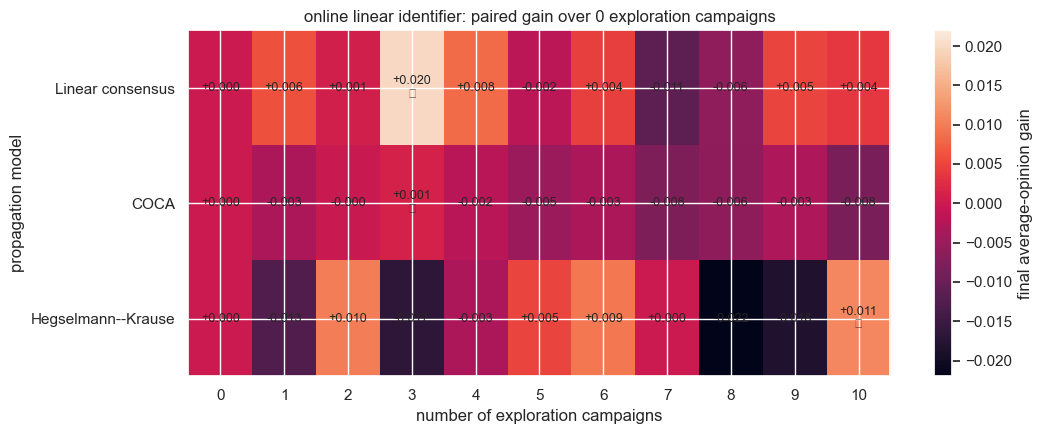

C:\Users\Chainsword\AppData\Local\Temp\ipykernel_5948\1560739962.py:100: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  plt.tight_layout()
c:\Users\Chainsword\anaconda3\envs\phd_rl_algos\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


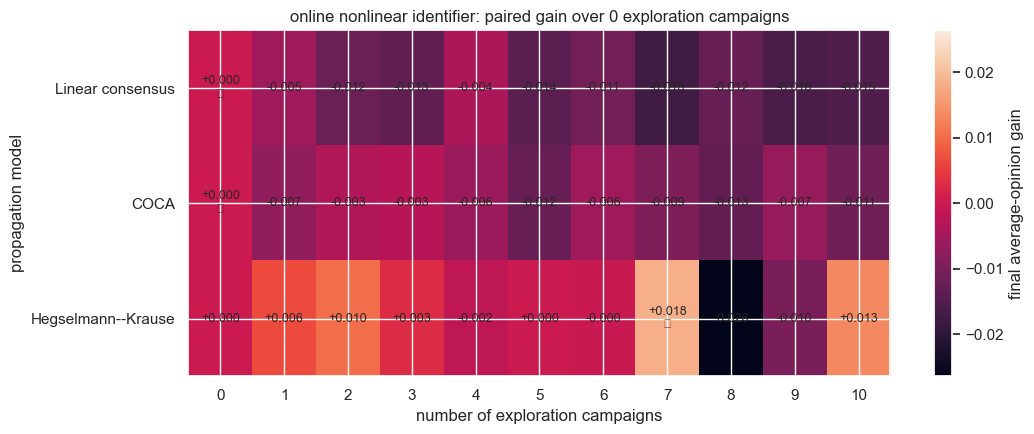

,dynamics,dynamics_label,model,model_label,exploration_campaigns_config,mean,std,count,sem,ci95
0,coca,COCA,online_linear_euler,online linear identifier,0,0.00000,0.00000,4,0.00000,0.00000
1,coca,COCA,online_linear_euler,online linear identifier,1,-0.00339,0.00309,4,0.00155,0.00303
2,coca,COCA,online_linear_euler,online linear identifier,2,-0.00029,0.00785,4,0.00393,0.00770
3,coca,COCA,online_linear_euler,online linear identifier,3,0.00109,0.00790,4,0.00395,0.00775
4,coca,COCA,online_linear_euler,online linear identifier,4,-0.00189,0.00112,4,0.00056,0.00110
...,...,...,...,...,...,...,...,...,...,...
61,laplacian,Linear consensus,online_nonlinear_lambda_mix,online nonlinear identifier,6,-0.01073,0.03782,4,0.01891,0.03706
62,laplacian,Linear consensus,online_nonlinear_lambda_mix,online nonlinear identifier,7,-0.01751,0.02734,4,0.01367,0.02679
63,laplacian,Linear consensus,online_nonlinear_lambda_mix,online nonlinear identifier,8,-0.01240,0.01283,4,0.00641,0.01257
64,laplacian,Linear consensus,online_nonlinear_lambda_mix,online nonlinear identifier,9,-0.01602,0.03154,4,0.01577,0.03091


In [11]:
# Pair every k with k=0 using the same dynamics, topology, initial state,
# and identifier. This is easier to interpret than raw final values:
# positive means that k exploration campaigns improved over no exploration.
pair_keys = [
    "dynamics",
    "dynamics_label",
    "topology_seed",
    "initial_seed",
    "trial_id",
    "model",
    "model_label",
]

zero = (
    summary_df[
        summary_df["exploration_campaigns_config"] == 0
    ][pair_keys + ["mean_end"]]
    .rename(columns={"mean_end": "mean_end_k0"})
)

paired_effect_df = summary_df.merge(
    zero,
    on=pair_keys,
    how="inner",
)
paired_effect_df["gain_vs_k0"] = (
    paired_effect_df["mean_end"]
    - paired_effect_df["mean_end_k0"]
)

paired_effect_summary = mean_ci95(
    paired_effect_df,
    "gain_vs_k0",
    [
        "dynamics",
        "dynamics_label",
        "model",
        "model_label",
        "exploration_campaigns_config",
    ],
)

def annotated_heatmap(
    table: pd.DataFrame,
    *,
    title: str,
    value_label: str,
    center_zero: bool = True,
) -> None:
    values = table.to_numpy(dtype=float)
    fig, ax = plt.subplots(
        figsize=(max(8, 0.72 * len(table.columns) + 3), 4.5)
    )
    if center_zero:
        vmax = float(np.nanmax(np.abs(values))) if values.size else 1.0
        vmax = max(vmax, 1e-12)
        im = ax.imshow(
            values,
            aspect="auto",
            vmin=-vmax,
            vmax=vmax,
        )
    else:
        im = ax.imshow(values, aspect="auto")

    ax.set_title(title)
    ax.set_xlabel("number of exploration campaigns")
    ax.set_ylabel("propagation model")
    ax.set_xticks(np.arange(len(table.columns)))
    ax.set_xticklabels(table.columns)
    ax.set_yticks(np.arange(len(table.index)))
    ax.set_yticklabels(table.index)

    for i in range(table.shape[0]):
        row = values[i]
        finite = np.isfinite(row)
        best_j = (
            int(np.nanargmax(row))
            if finite.any()
            else None
        )
        for j in range(table.shape[1]):
            val = values[i, j]
            if not np.isfinite(val):
                text = ""
            else:
                text = f"{val:+.3f}"
                if best_j == j:
                    text += "\n★"
            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=9,
            )

    fig.colorbar(im, ax=ax, label=value_label)
    plt.tight_layout()
    plt.show()


for model in LEARNED_POLICIES:
    sub = paired_effect_summary[
        paired_effect_summary["model"] == model
    ]
    table = (
        sub.pivot(
            index="dynamics_label",
            columns="exploration_campaigns_config",
            values="mean",
        )
        .reindex(
            index=[
                DYNAMICS_LABELS[d]
                for d in ENABLED_DYNAMICS
            ],
            columns=EXPLORATION_CAMPAIGN_COUNTS,
        )
    )
    annotated_heatmap(
        table,
        title=(
            f"{POLICY_LABELS[model]}: paired gain over "
            "0 exploration campaigns"
        ),
        value_label="final average-opinion gain",
        center_zero=True,
    )

display(
    paired_effect_summary.sort_values(
        [
            "dynamics_label",
            "model_label",
            "exploration_campaigns_config",
        ]
    ).round(5)
)


## 2. Which exploration count is selected?

This plot isolates the final decision of interest instead of mixing it with fit diagnostics and trajectory plots.


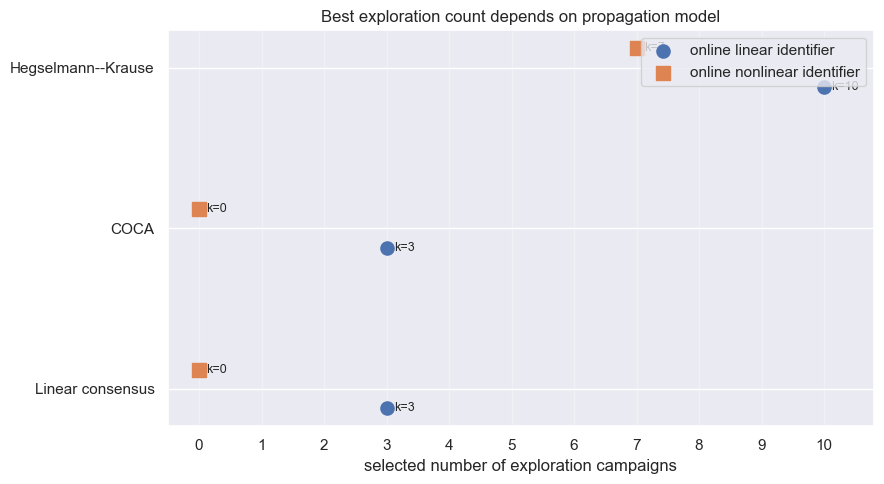

In [12]:
# Visual summary of the selected k for each propagation model.
fig, ax = plt.subplots(figsize=(9, 5))
y_labels = [
    DYNAMICS_LABELS[d]
    for d in ENABLED_DYNAMICS
]
y_pos = np.arange(len(y_labels), dtype=float)
offsets = {
    POLICY_LINEAR: -0.12,
    POLICY_NONLINEAR: 0.12,
}
markers = {
    POLICY_LINEAR: "o",
    POLICY_NONLINEAR: "s",
}

for model in LEARNED_POLICIES:
    sub = best_rows[
        best_rows["model"] == model
    ].set_index("dynamics_label")
    x = [
        float(
            sub.loc[label, "exploration_campaigns_config"]
        )
        for label in y_labels
    ]
    ax.scatter(
        x,
        y_pos + offsets[model],
        marker=markers[model],
        s=90,
        label=POLICY_LABELS[model],
    )
    for xi, yi in zip(x, y_pos + offsets[model]):
        ax.text(
            xi + 0.12,
            yi,
            f"k={int(xi)}",
            va="center",
            fontsize=9,
        )

ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels)
ax.set_xticks(EXPLORATION_CAMPAIGN_COUNTS)
ax.set_xlim(
    min(EXPLORATION_CAMPAIGN_COUNTS) - 0.5,
    max(EXPLORATION_CAMPAIGN_COUNTS) + 0.8,
)
ax.set_xlabel("selected number of exploration campaigns")
ax.set_title(
    "Best exploration count depends on propagation model"
)
ax.grid(True, axis="x", alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()


## 3. How costly is choosing the wrong count?

These heatmaps show performance relative to the best observed \(k\) within each propagation-model/identifier pair. Values near zero indicate a broad, forgiving plateau; large negative values indicate that the choice of \(k\) matters.


C:\Users\Chainsword\AppData\Local\Temp\ipykernel_5948\1560739962.py:100: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  plt.tight_layout()
c:\Users\Chainsword\anaconda3\envs\phd_rl_algos\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


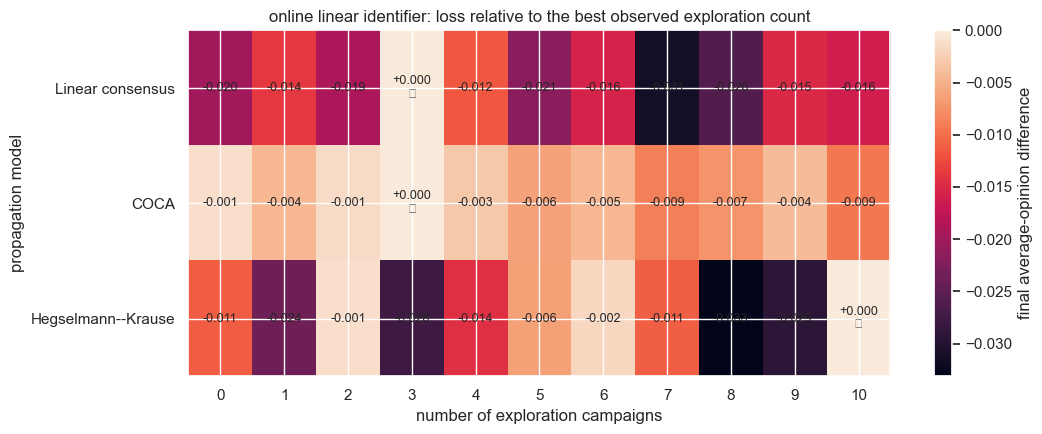

C:\Users\Chainsword\AppData\Local\Temp\ipykernel_5948\1560739962.py:100: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  plt.tight_layout()
c:\Users\Chainsword\anaconda3\envs\phd_rl_algos\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


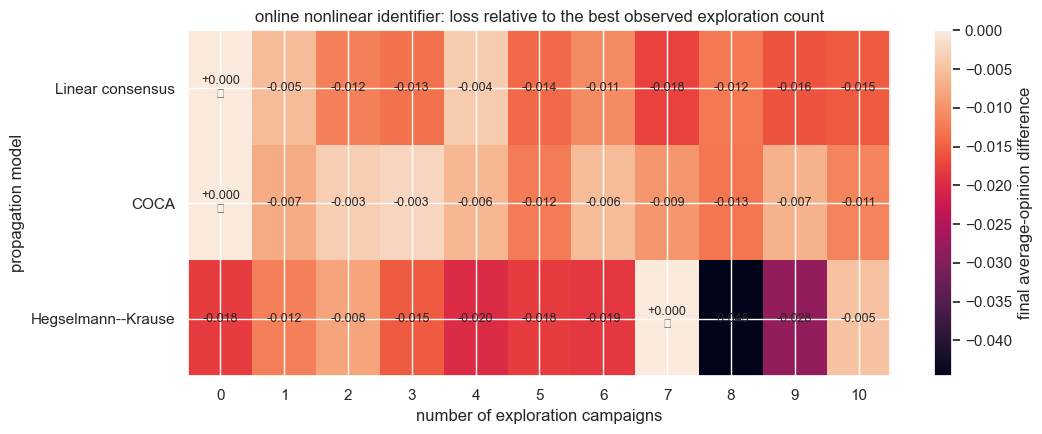

In [13]:
# Regret is expressed relative to the best observed k within each
# propagation-model/identifier combination. The best cell is 0; more
# negative cells indicate a more consequential choice of k.
best_means = (
    decision_summary.groupby(
        ["dynamics", "model"]
    )["mean"]
    .max()
    .rename("best_mean")
    .reset_index()
)
selection_sensitivity = decision_summary.merge(
    best_means,
    on=["dynamics", "model"],
    how="left",
)
selection_sensitivity["regret_vs_best_k"] = (
    selection_sensitivity["mean"]
    - selection_sensitivity["best_mean"]
)

for model in LEARNED_POLICIES:
    sub = selection_sensitivity[
        selection_sensitivity["model"] == model
    ]
    table = (
        sub.pivot(
            index="dynamics_label",
            columns="exploration_campaigns_config",
            values="regret_vs_best_k",
        )
        .reindex(
            index=[
                DYNAMICS_LABELS[d]
                for d in ENABLED_DYNAMICS
            ],
            columns=EXPLORATION_CAMPAIGN_COUNTS,
        )
    )
    annotated_heatmap(
        table,
        title=(
            f"{POLICY_LABELS[model]}: loss relative "
            "to the best observed exploration count"
        ),
        value_label="final average-opinion difference",
        center_zero=False,
    )

selection_sensitivity.to_csv(
    RESULTS_DIR / "exploration_selection_sensitivity.csv",
    index=False,
)


## 4. Raw exploration curves by propagation model

These are the conventional mean-with-95%-CI curves. They are useful for seeing the overall shape, but the paired and sensitivity plots above should be easier to interpret for model selection.


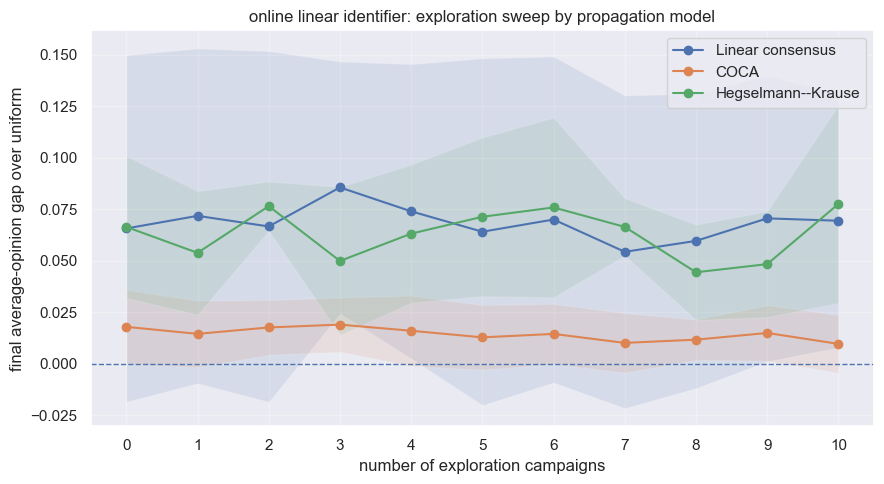

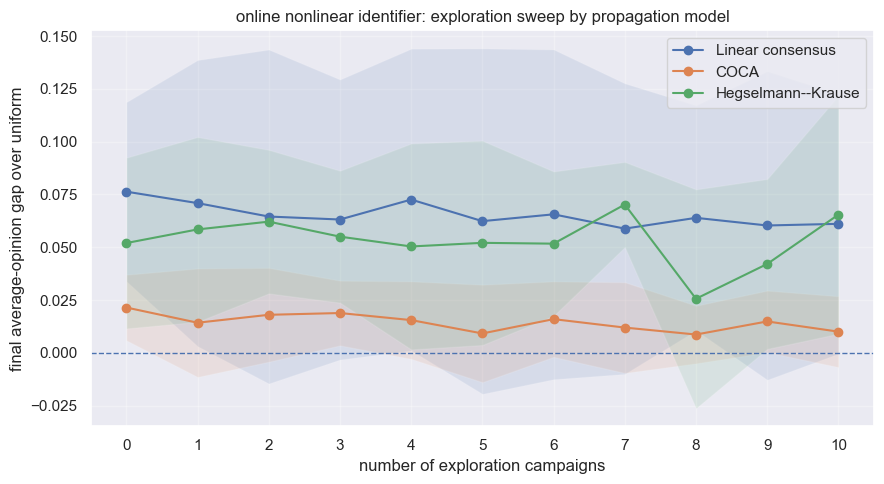

In [14]:
# Raw gap over uniform. One figure per identifier keeps the main comparison
# readable while showing propagation-model dependence.
for model in LEARNED_POLICIES:
    fig, ax = plt.subplots(figsize=(9, 5))
    sub_model = decision_summary[
        decision_summary["model"] == model
    ]
    for dynamics in ENABLED_DYNAMICS:
        sub = sub_model[
            sub_model["dynamics"] == dynamics
        ].sort_values("exploration_campaigns_config")
        x = sub["exploration_campaigns_config"].to_numpy(
            dtype=float
        )
        y = sub["mean"].to_numpy(dtype=float)
        e = sub["ci95"].to_numpy(dtype=float)
        ax.plot(
            x,
            y,
            marker="o",
            label=DYNAMICS_LABELS[dynamics],
        )
        ax.fill_between(
            x,
            y - e,
            y + e,
            alpha=0.12,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1)
    ax.set_xlabel("number of exploration campaigns")
    ax.set_ylabel("final average-opinion gap over uniform")
    ax.set_title(
        f"{POLICY_LABELS[model]}: exploration sweep "
        "by propagation model"
    )
    ax.set_xticks(EXPLORATION_CAMPAIGN_COUNTS)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()


# Optional diagnostics

Everything below is secondary to the decision plots above. Use these sections to understand *why* a particular exploration count performed well or poorly.


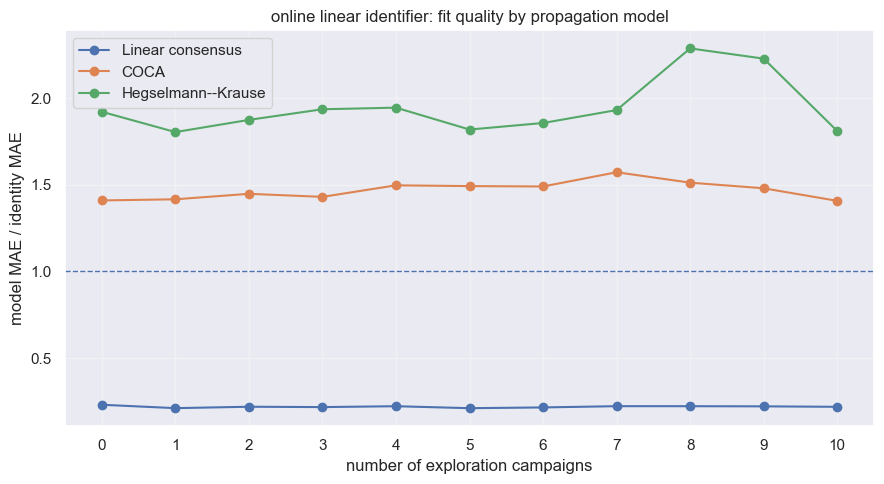

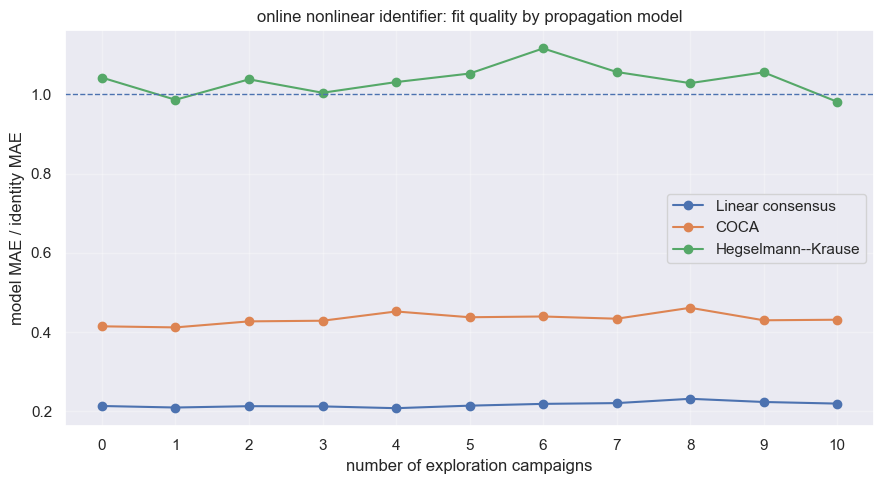

In [15]:
# Identifier fit quality is a secondary diagnostic. It becomes especially
# important when the true propagation law is nonlinear and the linear
# identifier is deliberately misspecified.
if not summary_df.empty:
    fit_summary = mean_ci95(
        summary_df.dropna(
            subset=["final_model_over_identity"]
        ),
        "final_model_over_identity",
        [
            "dynamics",
            "dynamics_label",
            "model",
            "model_label",
            "exploration_campaigns_config",
        ],
    )

    for model in LEARNED_POLICIES:
        fig, ax = plt.subplots(figsize=(9, 5))
        sub_model = fit_summary[
            fit_summary["model"] == model
        ]
        for dynamics in ENABLED_DYNAMICS:
            sub = sub_model[
                sub_model["dynamics"] == dynamics
            ].sort_values("exploration_campaigns_config")
            ax.plot(
                sub["exploration_campaigns_config"],
                sub["mean"],
                marker="o",
                label=DYNAMICS_LABELS[dynamics],
            )
        ax.axhline(1.0, linestyle="--", linewidth=1)
        ax.set_xlabel("number of exploration campaigns")
        ax.set_ylabel("model MAE / identity MAE")
        ax.set_title(
            f"{POLICY_LABELS[model]}: fit quality "
            "by propagation model"
        )
        ax.set_xticks(EXPLORATION_CAMPAIGN_COUNTS)
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best")
        plt.tight_layout()
        plt.show()


## Selected average-opinion trajectories


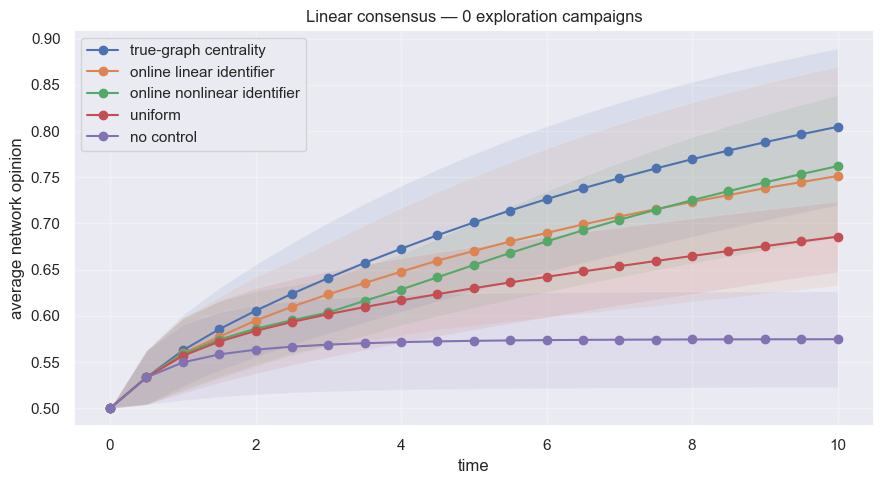

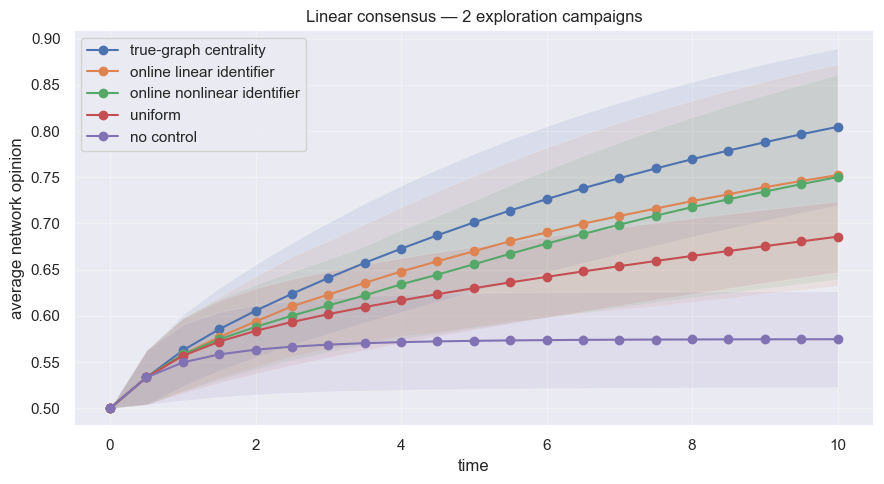

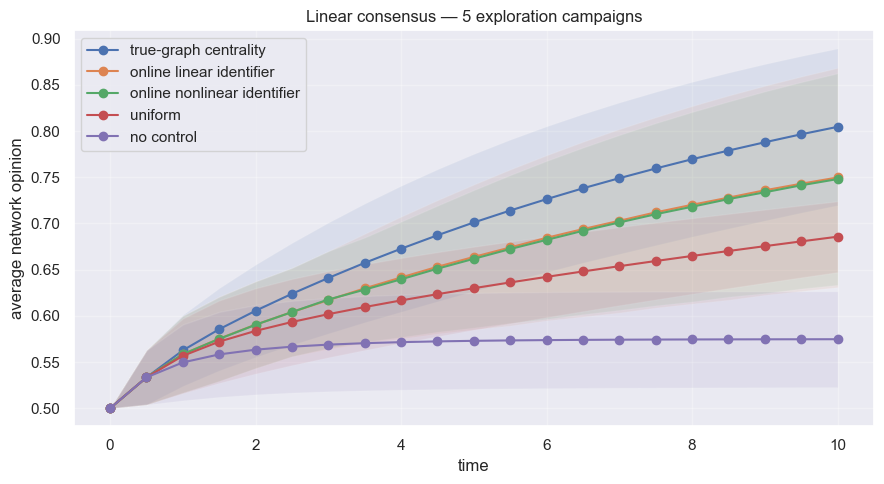

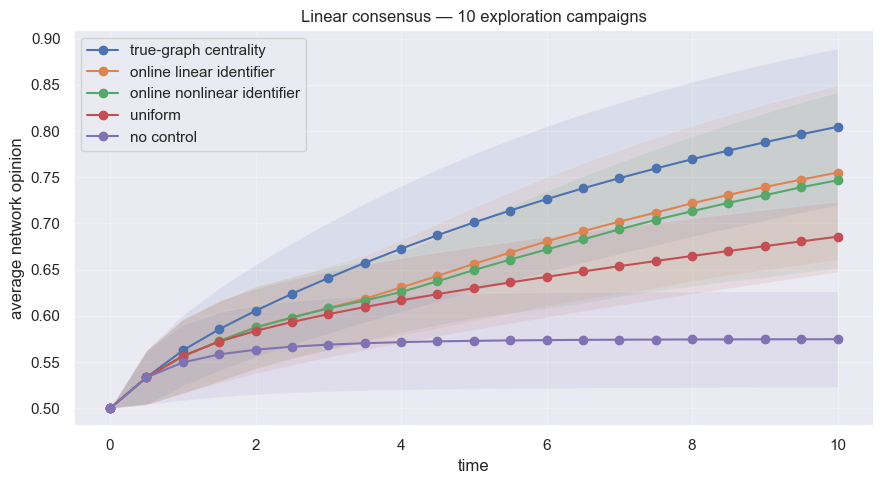

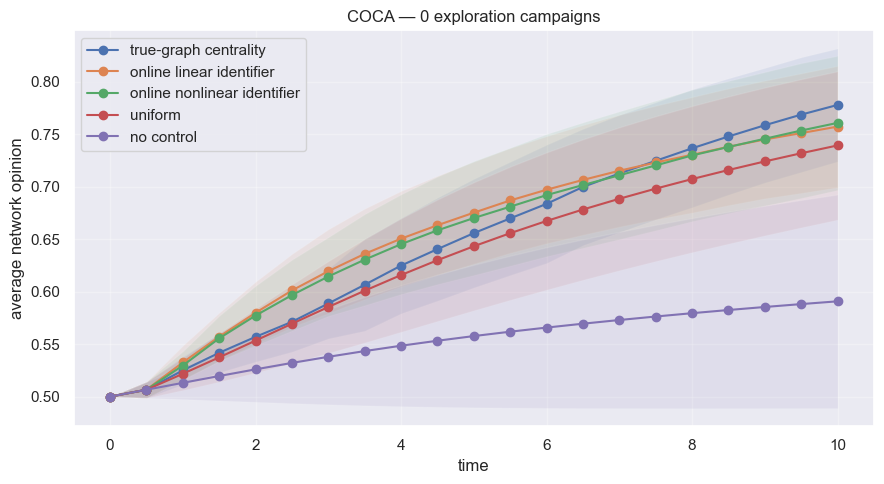

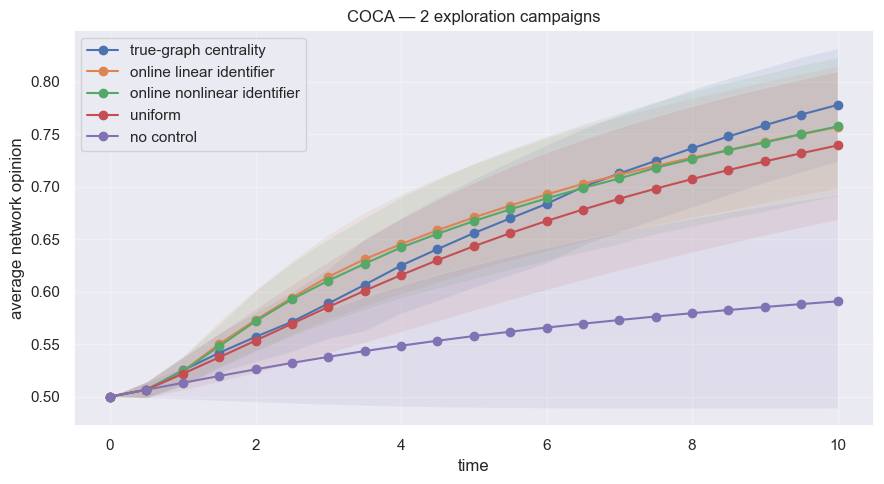

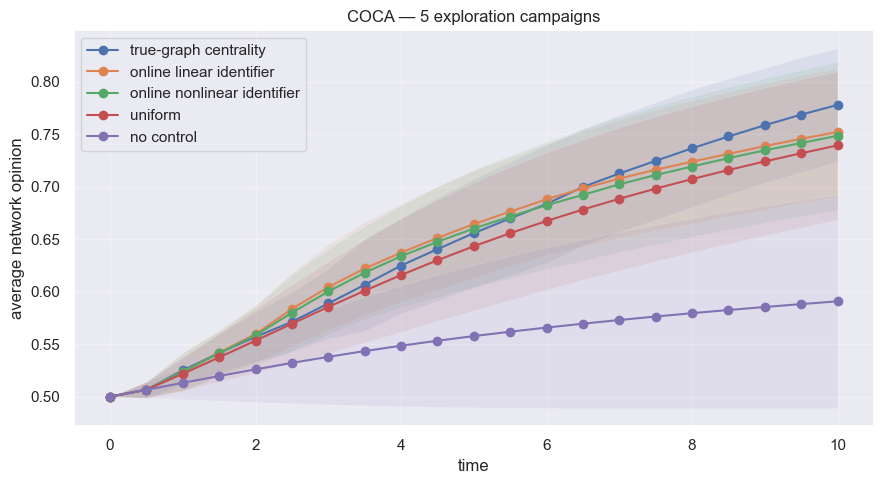

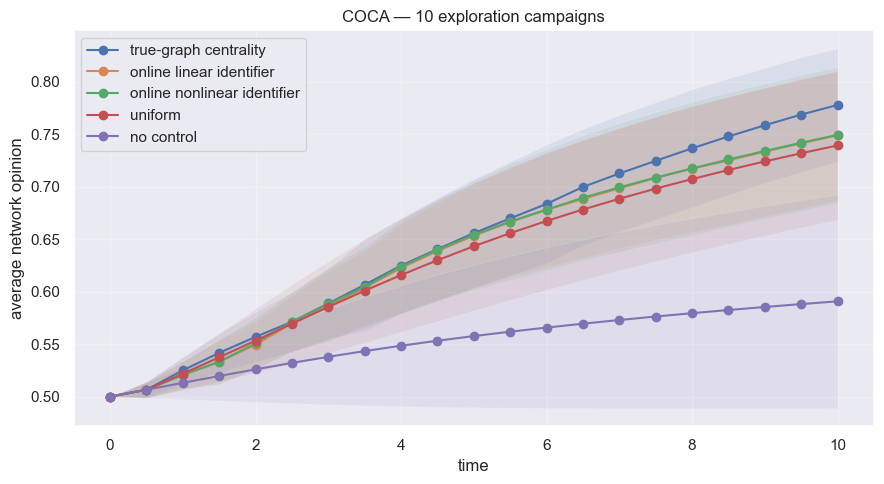

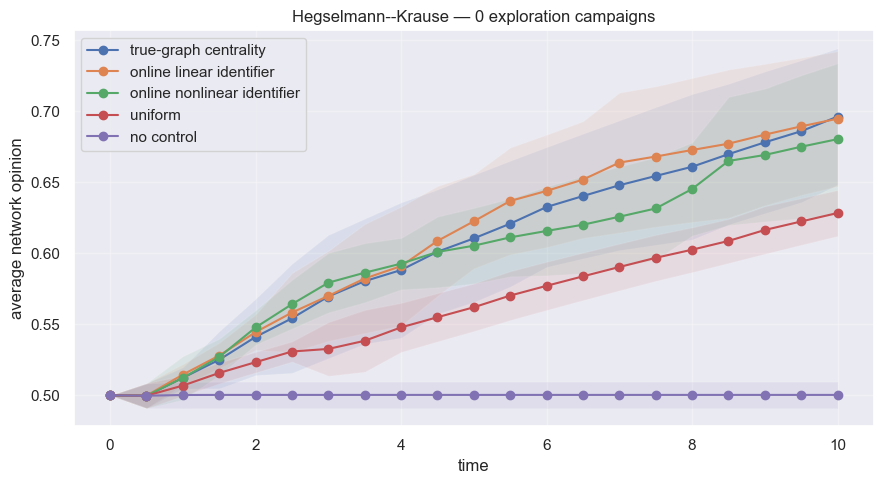

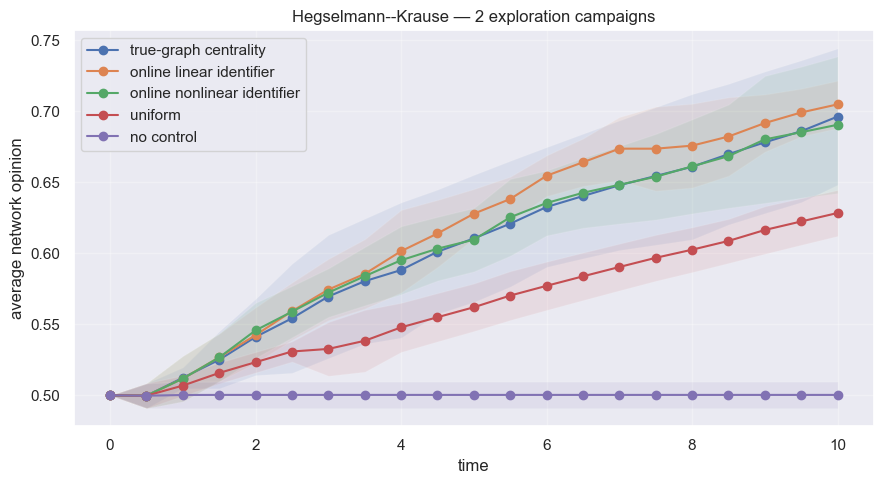

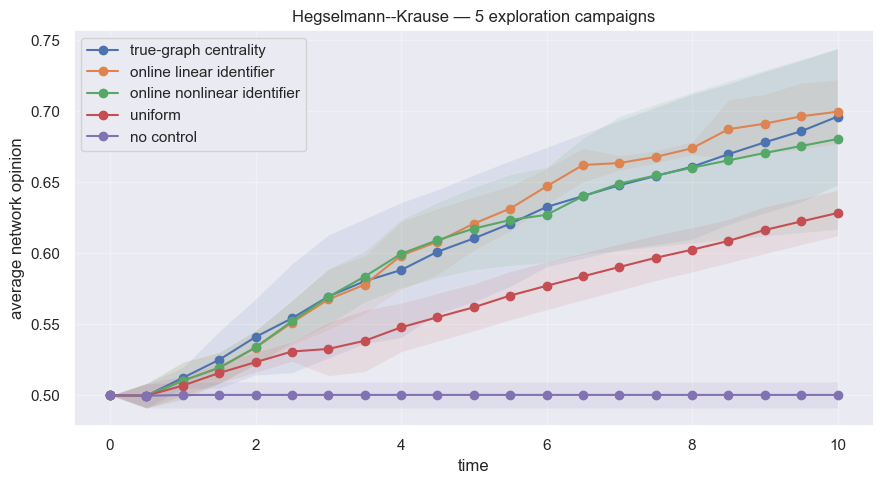

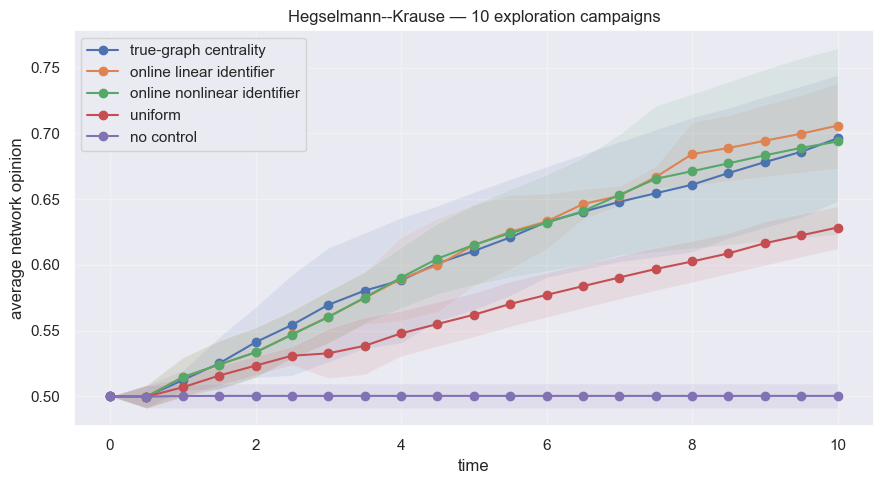

: 

In [ ]:
# Show only a few user-selected k values. The primary decision remains in the
# dashboard above; trajectories are for interpretation, not model selection.
for dynamics in ENABLED_DYNAMICS:
    for exploration_count in (
        SELECT_EXPLORATION_COUNTS_FOR_TRAJECTORIES
    ):
        df = trajectory_df[
            (
                trajectory_df["dynamics"]
                == dynamics
            )
            & (
                trajectory_df[
                    "exploration_campaigns_config"
                ]
                == exploration_count
            )
            & (
                trajectory_df["policy"].isin(
                    PLOT_POLICIES
                )
            )
        ].copy()
        if df.empty:
            continue

        fig, ax = plt.subplots(figsize=(9, 5))
        for policy in PLOT_POLICIES:
            sub = df[df["policy"] == policy]
            grouped = sub.groupby("time")["mean_opinion"]
            mean = grouped.mean()
            count = grouped.count()
            sem = (
                grouped.std(ddof=1)
                / np.sqrt(count.clip(lower=1))
            ).fillna(0.0)
            x = mean.index.to_numpy(dtype=float)
            y = mean.to_numpy(dtype=float)
            e = 1.96 * sem.to_numpy(dtype=float)
            ax.plot(
                x,
                y,
                marker="o",
                label=POLICY_LABELS.get(policy, policy),
            )
            ax.fill_between(
                x,
                y - e,
                y + e,
                alpha=0.10,
            )

        ax.set_title(
            f"{DYNAMICS_LABELS[dynamics]} — "
            f"{exploration_count} exploration campaigns"
        )
        ax.set_xlabel("time")
        ax.set_ylabel("average network opinion")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best")
        plt.tight_layout()
        plt.show()


## Extending the propagation-model sweep

To add a propagation model, enable its entry in `DYNAMICS_SPECS`. The run loop, tables, and plots will include it automatically.

Important interpretation notes:

- `laplacian` and `degroot` are aliases in the current environment, so they should not both be included.
- The linear identifier is correctly specified only for linear consensus. Under COCA, HK, FJ, nonlinear influence, or repulsion, it is intentionally a misspecified baseline.
- Graph-centrality recovery and graph-weighted target error are secondary diagnostics for nonlinear models; final average opinion and paired performance against uniform remain the primary metrics.
- Repulsion can fail to converge or produce qualitatively different behavior, so enable it as a separate robustness study rather than silently mixing it into the main paper result.
